In [2]:
# ============================================================
# WEEK 5 – HEALTHCONNECT EXPERIENCE LAB
# Data Analytics Track
# Author: Nancy Lee YIMBERE ALAPINI
# ============================================================

from google.colab import drive
import pandas as pd
import numpy as np

# Mount Google Drive
drive.mount('/content/drive')

# Load the original HealthConnect appointment dataset
file_path = "/content/drive/MyDrive/AnalystLab Africa/HealthConnect Experience Lab/Week 5/Data/HealthConnect_Appointment_Data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Rows: 5000
Columns: 18


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


# HealthConnect Experience Lab – Week 5 Analytics

**Track:** Data Analytics  
**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI  
**Analyst:** Nancy Lee YIMBERE ALAPINI  

## 1. Data Preparation & Quality Validation

This section validates the structure, quality, consistency, and analytical readiness of the HealthConnect Appointment Dataset before exploratory data analysis.

The original dataset is preserved unchanged. All validation, transformation, and analytical operations are performed within the notebook.

### 1.1 Dataset Loading and Initial Inspection

In [3]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [4]:
# Convert date variables to datetime format
df["booking_date"] = pd.to_datetime(
    df["booking_date"],
    format="%m/%d/%Y",
    errors="raise"
)

df["appointment_date"] = pd.to_datetime(
    df["appointment_date"],
    format="%m/%d/%Y",
    errors="raise"
)

# Verify converted data types
df[["booking_date", "appointment_date"]].dtypes

,0
booking_date,datetime64[ns]
appointment_date,datetime64[ns]


In [5]:
# Missing values audit

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2)
})

missing_summary

,Missing_Count,Missing_Percent
appointment_id,0,0.00
patient_id,0,0.00
gender,0,0.00
age,0,0.00
age_group,0,0.00
appointment_type,0,0.00
booking_date,0,0.00
appointment_date,0,0.00
appointment_day,0,0.00
appointment_time,0,0.00


In [6]:
# Validate whether missing reminder_channel values are structural

reminder_missing_check = pd.crosstab(
    df["reminder_sent"],
    df["reminder_channel"].isna(),
    margins=True
)

reminder_missing_check.columns = ["Channel_Present", "Channel_Missing", "Total"]

reminder_missing_check

,Channel_Present,Channel_Missing,Total
reminder_sent,,,
No,0,1366,1366
Yes,3634,0,3634
All,3634,1366,5000


In [7]:
# Duplicate and identifier integrity checks

integrity_summary = pd.DataFrame({
    "Check": [
        "Total appointment records",
        "Unique appointment IDs",
        "Duplicate appointment IDs",
        "Exact duplicate rows",
        "Distinct patient IDs"
    ],
    "Result": [
        len(df),
        df["appointment_id"].nunique(),
        df["appointment_id"].duplicated().sum(),
        df.duplicated().sum(),
        df["patient_id"].nunique()
    ]
})

integrity_summary

,Check,Result
0,Total appointment records,5000
1,Unique appointment IDs,5000
2,Duplicate appointment IDs,0
3,Exact duplicate rows,0
4,Distinct patient IDs,1696


In [8]:
# Categorical consistency checks

categorical_columns = [
    "gender",
    "age_group",
    "appointment_type",
    "appointment_day",
    "appointment_time",
    "reminder_sent",
    "reminder_channel",
    "appointment_outcome"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


--- gender ---
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

--- age_group ---
age_group
18-24     564
25-34     783
35-44     819
45-54     793
55-64     800
65+      1241
Name: count, dtype: int64

--- appointment_type ---
appointment_type
Diagnostic Test             593
Follow-up                  1421
General Consultation       2086
Specialist Consultation     900
Name: count, dtype: int64

--- appointment_day ---
appointment_day
Friday       728
Monday       701
Saturday     724
Sunday       737
Thursday     684
Tuesday      689
Wednesday    737
Name: count, dtype: int64

--- appointment_time ---
appointment_time
Afternoon    2094
Evening       679
Morning      2227
Name: count, dtype: int64

--- reminder_sent ---
reminder_sent
No     1366
Yes    3634
Name: count, dtype: int64

--- reminder_channel ---
reminder_channel
Email        533
SMS         2000
WhatsApp    1101
NaN         1366
Name: count, dtype: int64

---

In [9]:
# Numerical variables profiling

numeric_columns = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]

numeric_profile = df[numeric_columns].describe().T

numeric_profile["missing"] = df[numeric_columns].isna().sum()
numeric_profile["distinct"] = df[numeric_columns].nunique()

numeric_profile[
    ["count", "missing", "distinct", "min", "max", "mean", "std"]
].round(2)

,count,missing,distinct,min,max,mean,std
age,5000.0,0,63,18.0,80.0,48.79,18.14
booking_lead_days,5000.0,0,61,0.0,60.0,29.64,17.40
previous_appointments,5000.0,0,12,0.0,11.0,3.01,1.74
previous_no_shows,5000.0,0,6,0.0,5.0,0.54,0.75
distance_to_clinic_km,4910.0,90,335,0.5,45.0,10.11,6.59
waiting_time_minutes,4940.0,60,62,2.0,68.0,24.19,10.86


In [10]:
# Cross-column logical consistency checks

# 1. Previous no-shows cannot exceed previous appointments
history_valid = (
    df["previous_no_shows"] <= df["previous_appointments"]
)

# 2. Age must correspond to recorded age group
age_group_valid = (
    ((df["age"].between(18, 24)) & (df["age_group"] == "18-24")) |
    ((df["age"].between(25, 34)) & (df["age_group"] == "25-34")) |
    ((df["age"].between(35, 44)) & (df["age_group"] == "35-44")) |
    ((df["age"].between(45, 54)) & (df["age_group"] == "45-54")) |
    ((df["age"].between(55, 64)) & (df["age_group"] == "55-64")) |
    ((df["age"] >= 65) & (df["age_group"] == "65+"))
)

# 3. Booking lead days must equal appointment date minus booking date
lead_days_valid = (
    (df["appointment_date"] - df["booking_date"]).dt.days
    == df["booking_lead_days"]
)

# 4. Booking date cannot occur after appointment date
date_order_valid = (
    df["booking_date"] <= df["appointment_date"]
)

# 5. Recorded appointment day must match appointment date
appointment_day_valid = (
    df["appointment_date"].dt.day_name()
    == df["appointment_day"]
)

logical_checks = pd.DataFrame({
    "Check": [
        "Previous no-shows <= previous appointments",
        "Age consistent with age group",
        "Booking lead days consistent with dates",
        "Booking date <= appointment date",
        "Appointment day consistent with appointment date"
    ],
    "Valid_Rows": [
        history_valid.sum(),
        age_group_valid.sum(),
        lead_days_valid.sum(),
        date_order_valid.sum(),
        appointment_day_valid.sum()
    ],
    "Invalid_Rows": [
        (~history_valid).sum(),
        (~age_group_valid).sum(),
        (~lead_days_valid).sum(),
        (~date_order_valid).sum(),
        (~appointment_day_valid).sum()
    ]
})

logical_checks

,Check,Valid_Rows,Invalid_Rows
0,Previous no-shows <= previous appointments,5000,0
1,Age consistent with age group,5000,0
2,Booking lead days consistent with dates,5000,0
3,Booking date <= appointment date,5000,0
4,Appointment day consistent with appointment date,5000,0


In [11]:
# Patient-level demographic consistency checks

patient_demographic_consistency = (
    df.groupby("patient_id")
      .agg(
          Gender_Count=("gender", "nunique"),
          Age_Count=("age", "nunique"),
          AgeGroup_Count=("age_group", "nunique")
      )
)

demographic_qa = pd.DataFrame({
    "Check": [
        "Patients with >1 recorded gender",
        "Patients with >1 recorded exact age",
        "Patients with >1 recorded age group"
    ],
    "Affected_Patients": [
        (patient_demographic_consistency["Gender_Count"] > 1).sum(),
        (patient_demographic_consistency["Age_Count"] > 1).sum(),
        (patient_demographic_consistency["AgeGroup_Count"] > 1).sum()
    ],
    "Total_Patients": [
        df["patient_id"].nunique(),
        df["patient_id"].nunique(),
        df["patient_id"].nunique()
    ]
})

demographic_qa["Affected_Percent"] = (
    demographic_qa["Affected_Patients"]
    / demographic_qa["Total_Patients"]
    * 100
).round(2)

demographic_qa

,Check,Affected_Patients,Total_Patients,Affected_Percent
0,Patients with >1 recorded gender,1058,1696,62.38
1,Patients with >1 recorded exact age,1385,1696,81.66
2,Patients with >1 recorded age group,1287,1696,75.88


In [12]:
# Patient-level chronological consistency of recorded history variables

def is_monotonic_by_date(group, column):
    ordered = group.sort_values("appointment_date")
    values = ordered[column].to_numpy()
    return (values[1:] >= values[:-1]).all()

previous_appointments_check = (
    df.groupby("patient_id")
      .apply(
          lambda g: is_monotonic_by_date(g, "previous_appointments"),
          include_groups=False
      )
)

previous_no_shows_check = (
    df.groupby("patient_id")
      .apply(
          lambda g: is_monotonic_by_date(g, "previous_no_shows"),
          include_groups=False
      )
)

history_qa = pd.DataFrame({
    "Check": [
        "Previous appointments chronology",
        "Previous no-shows chronology"
    ],
    "Monotonic_Patients": [
        previous_appointments_check.sum(),
        previous_no_shows_check.sum()
    ],
    "Non_Monotonic_Patients": [
        (~previous_appointments_check).sum(),
        (~previous_no_shows_check).sum()
    ],
    "Total_Patients": [
        len(previous_appointments_check),
        len(previous_no_shows_check)
    ]
})

history_qa["Non_Monotonic_Percent"] = (
    history_qa["Non_Monotonic_Patients"]
    / history_qa["Total_Patients"]
    * 100
).round(2)

history_qa

,Check,Monotonic_Patients,Non_Monotonic_Patients,Total_Patients,Non_Monotonic_Percent
0,Previous appointments chronology,701,995,1696,58.67
1,Previous no-shows chronology,937,759,1696,44.75


In [13]:
# Check whether patients can have multiple appointments on the same date

same_day_appointments = (
    df.groupby(["patient_id", "appointment_date"])
      .size()
      .reset_index(name="Appointments_Same_Day")
)

same_day_duplicates = same_day_appointments[
    same_day_appointments["Appointments_Same_Day"] > 1
]

print("Patient-date combinations with multiple appointments:",
      len(same_day_duplicates))

print("Patients affected:",
      same_day_duplicates["patient_id"].nunique())

same_day_duplicates.head(20)

Patient-date combinations with multiple appointments: 15
Patients affected: 15


,patient_id,appointment_date,Appointments_Same_Day
104,P-0039,2025-03-15,2
639,P-0227,2025-08-24,2
767,P-0273,2025-08-28,2
1091,P-0391,2026-01-20,2
1609,P-0567,2026-01-30,2
1628,P-0575,2025-03-18,2
2242,P-0796,2026-06-05,2
2679,P-0939,2025-06-02,2
3217,P-1139,2025-12-21,2
3316,P-1171,2026-01-30,2


In [14]:
# Investigate the impact of same-day appointments on history monotonicity

same_day_patient_ids = set(same_day_duplicates["patient_id"])

print("Patients with multiple appointments on the same date:")
print(sorted(same_day_patient_ids))
print("\nNumber of affected patients:", len(same_day_patient_ids))

# Display the detailed records for these patients
same_day_details = (
    df[df["patient_id"].isin(same_day_patient_ids)]
    .sort_values(["patient_id", "appointment_date", "appointment_id"])
    [
        [
            "patient_id",
            "appointment_id",
            "appointment_date",
            "previous_appointments",
            "previous_no_shows"
        ]
    ]
)

same_day_details

Patients with multiple appointments on the same date:
['P-0039', 'P-0227', 'P-0273', 'P-0391', 'P-0567', 'P-0575', 'P-0796', 'P-0939', 'P-1139', 'P-1171', 'P-1214', 'P-1608', 'P-1623', 'P-1742', 'P-1752']

Number of affected patients: 15


,patient_id,appointment_id,appointment_date,previous_appointments,previous_no_shows
496,P-0039,HC-00497,2025-03-06,2,0
1357,P-0039,HC-01358,2025-03-15,2,0
3307,P-0039,HC-03308,2025-03-15,4,1
737,P-0227,HC-00738,2025-07-02,4,0
1152,P-0227,HC-01153,2025-08-24,3,0
...,...,...,...,...,...
4670,P-1752,HC-04671,2025-02-22,4,0
2383,P-1752,HC-02384,2025-08-03,5,0
2600,P-1752,HC-02601,2026-04-17,3,1
3469,P-1752,HC-03470,2026-04-19,2,1


In [15]:
# Sensitivity check for same-day appointments
# Compare two valid row-ordering conventions within the same appointment date

def non_monotonic_patients(df, variable, tie_breaker):
    ordered = df.sort_values(
        ["patient_id", "appointment_date", tie_breaker]
    )

    result = set()

    for patient_id, group in ordered.groupby("patient_id"):
        values = group[variable].tolist()

        if any(values[i] < values[i-1] for i in range(1, len(values))):
            result.add(patient_id)

    return result


# Ordering 1: original dataset row order
df_order = df.reset_index().rename(columns={"index": "original_row"})

pa_original = non_monotonic_patients(
    df_order, "previous_appointments", "original_row"
)

pns_original = non_monotonic_patients(
    df_order, "previous_no_shows", "original_row"
)

# Ordering 2: appointment_id as a deterministic tie-breaker
pa_id = non_monotonic_patients(
    df_order, "previous_appointments", "appointment_id"
)

pns_id = non_monotonic_patients(
    df_order, "previous_no_shows", "appointment_id"
)

# Patients whose classification changes depending on same-day ordering
pa_sensitive = pa_original.symmetric_difference(pa_id)
pns_sensitive = pns_original.symmetric_difference(pns_id)

print("PREVIOUS APPOINTMENTS")
print("Original-row ordering:", len(pa_original))
print("Appointment-ID ordering:", len(pa_id))
print("Patients sensitive to ordering:", sorted(pa_sensitive))

print("\nPREVIOUS NO-SHOWS")
print("Original-row ordering:", len(pns_original))
print("Appointment-ID ordering:", len(pns_id))
print("Patients sensitive to ordering:", sorted(pns_sensitive))

print("\nAre all sensitive cases among same-day patients?")
print("Previous appointments:", pa_sensitive.issubset(same_day_patient_ids))
print("Previous no-shows:", pns_sensitive.issubset(same_day_patient_ids))

PREVIOUS APPOINTMENTS
Original-row ordering: 995
Appointment-ID ordering: 995
Patients sensitive to ordering: []

PREVIOUS NO-SHOWS
Original-row ordering: 759
Appointment-ID ordering: 759
Patients sensitive to ordering: []

Are all sensitive cases among same-day patients?
Previous appointments: True
Previous no-shows: True


### Data Preparation & Quality Validation — Conclusion

The HealthConnect appointment dataset contains **5,000 appointment records**, representing **1,696 distinct patient IDs**. Data preparation and quality validation confirmed that appointment IDs are unique, no exact duplicate rows are present, date fields were successfully converted to datetime format, and the main categorical and numerical variables are structurally suitable for appointment-level analysis.

Missing data are limited to **distance_to_clinic_km (90 records; 1.80%)** and **waiting_time_minutes (60 records; 1.20%)**. The **1,366 missing reminder_channel values (27.32%)** correspond exclusively to appointments where `reminder_sent = No` and are therefore treated as **structurally not applicable rather than unexplained missingness**. No imputation was performed.

Row-level logical validation identified no inconsistencies between age and age group, booking lead time and appointment dates, appointment day and appointment date, booking and appointment date order, or recorded previous no-shows relative to previous appointments.

However, patient-level quality checks identified substantial inconsistencies across repeated patient IDs. Among the 1,696 patients, **1,058 (62.38%)** have more than one recorded gender, **1,385 (81.66%)** more than one exact age, and **1,287 (75.88%)** more than one age group. Historical variables also show non-monotonic sequences for **995 patients (58.67%)** for `previous_appointments` and **759 patients (44.75%)** for `previous_no_shows`. These results remained unchanged after testing appointment-ID ordering for patients with multiple appointments on the same date.

Consequently, the **appointment record is retained as the primary unit of analysis**. Patient demographic and historical variables will be interpreted as characteristics recorded at the appointment level, and no longitudinal patient history will be reconstructed from these fields.

No records were removed solely because of these patient-level inconsistencies. The identified limitations will instead be carried forward explicitly into the EDA, interpretation of findings, and final reporting.

**Data preparation and quality validation are therefore considered complete. The analysis now proceeds to Exploratory Data Analysis (EDA), structured around the validated HealthConnect business questions.**

# 2. Exploratory Data Analysis (EDA)

The Exploratory Data Analysis is structured around the validated HealthConnect business questions defined during the Week 4 foundation stage.

The objective is to identify and quantify appointment attendance and no-show patterns, evaluate the analytical hypotheses where relevant, and establish traceable evidence for subsequent KPI interpretation, business insights, and recommendations.

## BQ1 — Overall Appointment Outcome

**Business Question:**  
What is the overall distribution of appointment outcomes, and what is the relative extent of no-shows?

**Analytical objective:**  
Establish the baseline distribution of appointment outcomes and quantify the overall no-show level before investigating potential variation across appointment, scheduling, reminder, accessibility, history, and patient-characteristic dimensions.

**Analysis plan:**
1. Calculate appointment outcome counts.
2. Calculate the share of each appointment outcome across all appointment records.
3. Define the analytical population for the No-Show Rate.
4. Calculate the overall No-Show Rate.
5. Visualise the baseline outcome distribution.
6. Interpret the findings and establish the baseline for subsequent EDA.

In [16]:
# BQ1.1 — Overall appointment outcome distribution

outcome_distribution = (
    df["appointment_outcome"]
    .value_counts()
    .rename_axis("Appointment_Outcome")
    .reset_index(name="Appointment_Count")
)

outcome_distribution["Share_Percent"] = (
    outcome_distribution["Appointment_Count"] / len(df) * 100
).round(2)

outcome_distribution

,Appointment_Outcome,Appointment_Count,Share_Percent
0,No-Show,2423,48.46
1,Attended,2314,46.28
2,Cancelled,263,5.26


In [17]:
# BQ1.2 — No-Show Rate among non-cancelled appointments

attended_count = (df["appointment_outcome"] == "Attended").sum()
no_show_count = (df["appointment_outcome"] == "No-Show").sum()
cancelled_count = (df["appointment_outcome"] == "Cancelled").sum()

analytical_population = attended_count + no_show_count

no_show_rate = (
    no_show_count / analytical_population * 100
)

bq1_kpi_summary = pd.DataFrame({
    "Metric": [
        "Attended Appointments",
        "No-Show Appointments",
        "Cancelled Appointments",
        "Non-Cancelled Analytical Population",
        "No-Show Rate (%)"
    ],
    "Value": [
        attended_count,
        no_show_count,
        cancelled_count,
        analytical_population,
        round(no_show_rate, 2)
    ]
})

bq1_kpi_summary

,Metric,Value
0,Attended Appointments,2314.00
1,No-Show Appointments,2423.00
2,Cancelled Appointments,263.00
3,Non-Cancelled Analytical Population,4737.00
4,No-Show Rate (%),51.15


### BQ1 — Initial Finding: Overall Appointment Outcome

Among the 5,000 appointment records, 2,423 (48.46%) were recorded as No-Show, 2,314 (46.28%) as Attended, and 263 (5.26%) as Cancelled.

For the No-Show Rate KPI, cancelled appointments are excluded from the analytical denominator. The resulting non-cancelled analytical population is 4,737 appointments, of which 2,423 were No-Shows.

**No-Show Rate = 51.15%.**

**Initial interpretation:** No-Shows account for slightly more than half of all non-cancelled appointments, indicating that missed appointment attendance represents a substantial issue within the observed HealthConnect appointment records.

This result establishes the overall baseline for subsequent diagnostic analysis. The next analyses will examine how the No-Show Rate varies across appointment, scheduling, reminder, accessibility, operational, historical, and recorded patient characteristics.

**Interpretation guardrail:** This baseline is descriptive. It identifies the extent of the observed no-show outcome but does not explain its causes.

## BQ2 — Appointment & Scheduling Context

### BQ2.1 — Appointment Type

**Business Question:** How do no-show patterns vary across appointment types?

**Hypothesis H2a:** The no-show rate differs across appointment types.

**Analytical population:** Non-cancelled appointments only (Attended + No-Show).

**Primary metric:** No-Show Rate (%) by appointment type.

The overall No-Show Rate of 51.15% is used as a descriptive reference for comparison, not as an external benchmark or performance target.

In [18]:
# BQ2.1 — No-Show Rate by appointment type

bq2_type = (
    df[df["appointment_outcome"].isin(["Attended", "No-Show"])]
    .groupby("appointment_type")["appointment_outcome"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

# Analytical population by appointment type
bq2_type["Analytical_Population"] = (
    bq2_type["Attended"] + bq2_type["No-Show"]
)

# No-Show Rate
bq2_type["No_Show_Rate_Percent"] = (
    bq2_type["No-Show"] /
    bq2_type["Analytical_Population"] * 100
).round(2)

# Difference from overall No-Show Rate
bq2_type["Gap_vs_Overall_pp"] = (
    bq2_type["No_Show_Rate_Percent"] - no_show_rate
).round(2)

# Sort from highest to lowest No-Show Rate
bq2_type = bq2_type[
    [
        "appointment_type",
        "Attended",
        "No-Show",
        "Analytical_Population",
        "No_Show_Rate_Percent",
        "Gap_vs_Overall_pp"
    ]
].sort_values(
    "No_Show_Rate_Percent",
    ascending=False
).reset_index(drop=True)

bq2_type

appointment_outcome,appointment_type,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
0,Follow-up,616,728,1344,54.17,3.02
1,Diagnostic Test,272,295,567,52.03,0.88
2,Specialist Consultation,419,427,846,50.47,-0.68
3,General Consultation,1007,973,1980,49.14,-2.01


In [19]:
# BQ2.1 — Statistical evaluation of H2a
# Association between appointment type and appointment outcome
# Population: non-cancelled appointments only

from scipy.stats import chi2_contingency

bq2_type_contingency = pd.crosstab(
    df.loc[
        df["appointment_outcome"].isin(["Attended", "No-Show"]),
        "appointment_type"
    ],
    df.loc[
        df["appointment_outcome"].isin(["Attended", "No-Show"]),
        "appointment_outcome"
    ]
)

chi2, p_value, dof, expected = chi2_contingency(bq2_type_contingency)

print("Contingency table:")
display(bq2_type_contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")
print(f"Minimum expected cell count: {expected.min():.2f}")

Contingency table:


appointment_outcome,Attended,No-Show
appointment_type,,
Diagnostic Test,272,295
Follow-up,616,728
General Consultation,1007,973
Specialist Consultation,419,427


Chi-square statistic: 8.4221
Degrees of freedom: 3
P-value: 0.0380
Minimum expected cell count: 276.98


In [20]:
# BQ2.1 — Effect size for the association: Cramér's V

import numpy as np

n = bq2_type_contingency.to_numpy().sum()
r, k = bq2_type_contingency.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1))
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.0422


#### BQ2.1 — Appointment Type: Evidence and Interpretation

**Hypothesis H2a:** The no-show rate differs across appointment types.

**Evidence.** Among non-cancelled appointments, no-show rates ranged from **49.14% for General Consultations** to **54.17% for Follow-up appointments**, representing an observed spread of **5.03 percentage points**. Relative to the overall no-show rate of **51.15%**, Follow-up appointments were **3.02 pp above** the overall reference, while General Consultations were **2.01 pp below** it.

A chi-square test indicated a statistically significant association between appointment type and attendance outcome, **χ²(3) = 8.42, p = 0.038**. However, the corresponding effect size was very small (**Cramér's V = 0.042**).

**Finding.** H2a is statistically supported: no-show patterns are not identical across appointment types. The highest observed no-show rate occurred among Follow-up appointments, while General Consultations recorded the lowest rate.

**Interpretation.** Although appointment type is associated with attendance outcome, the very small effect size indicates that appointment type alone provides limited discriminatory power for explaining no-show behaviour. Statistical significance should therefore not be interpreted as evidence of a strong operational relationship.

**Business implication.** Follow-up appointments may warrant closer investigation because they combine the highest observed no-show rate (**54.17%**) with a substantial analytical population (**n = 1,344**). However, appointment type alone does not provide sufficient evidence for a targeted intervention. Its pattern should be examined alongside scheduling, reminder, accessibility and recorded-history factors before prioritising action.

**Evidence level:** Statistically detectable association, but very small effect size.  
**Decision status:** Diagnostic signal — further segmentation required before action.

### BQ2.2 — Appointment Day

**Hypothesis H2b:** The no-show rate differs across appointment days.

**Analytical population:** Non-cancelled appointments (`Attended` + `No-Show`).

**Primary metric:** No-Show Rate (%).

The analysis first compares observed no-show rates across appointment days and quantifies their deviation from the overall no-show rate. Statistical evidence and effect size will only be evaluated after examining the descriptive pattern.

In [21]:
# BQ2.2 — Appointment Day
# Descriptive comparison of no-show rates across appointment days

# Keep only the analytical population
bq2_day_data = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

# Create outcome counts by appointment day
bq2_day = (
    bq2_day_data
    .groupby(["appointment_day", "appointment_outcome"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Analytical population by day
bq2_day["Analytical_Population"] = (
    bq2_day["Attended"] + bq2_day["No-Show"]
)

# No-show rate
bq2_day["No_Show_Rate_Percent"] = (
    bq2_day["No-Show"] /
    bq2_day["Analytical_Population"] * 100
)

# Gap versus overall no-show rate
overall_nsr = (
    (bq2_day_data["appointment_outcome"] == "No-Show").mean() * 100
)

bq2_day["Gap_vs_Overall_pp"] = (
    bq2_day["No_Show_Rate_Percent"] - overall_nsr
)

# Sort from highest to lowest no-show rate
bq2_day = (
    bq2_day
    .sort_values("No_Show_Rate_Percent", ascending=False)
    .reset_index(drop=True)
)

# Round presentation metrics
bq2_day["No_Show_Rate_Percent"] = bq2_day["No_Show_Rate_Percent"].round(2)
bq2_day["Gap_vs_Overall_pp"] = bq2_day["Gap_vs_Overall_pp"].round(2)

bq2_day

appointment_outcome,appointment_day,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
0,Monday,307,348,655,53.13,1.98
1,Sunday,332,372,704,52.84,1.69
2,Wednesday,327,366,693,52.81,1.66
3,Thursday,309,335,644,52.02,0.87
4,Saturday,344,339,683,49.63,-1.52
5,Tuesday,338,324,662,48.94,-2.21
6,Friday,357,339,696,48.71,-2.44


In [22]:
# H2b — Chi-square test: Appointment Day × Appointment Outcome

from scipy.stats import chi2_contingency

bq2_day_contingency = pd.crosstab(
    bq2_day_data["appointment_day"],
    bq2_day_data["appointment_outcome"]
)

chi2_day, p_day, dof_day, expected_day = chi2_contingency(
    bq2_day_contingency
)

print("Contingency table:")
display(bq2_day_contingency)

print(f"Chi-square statistic: {chi2_day:.4f}")
print(f"Degrees of freedom: {dof_day}")
print(f"P-value: {p_day:.4f}")
print(f"Minimum expected cell count: {expected_day.min():.2f}")

Contingency table:


appointment_outcome,Attended,No-Show
appointment_day,,
Friday,357,339
Monday,307,348
Saturday,344,339
Sunday,332,372
Thursday,309,335
Tuesday,338,324
Wednesday,327,366


Chi-square statistic: 6.3771
Degrees of freedom: 6
P-value: 0.3823
Minimum expected cell count: 314.59


In [23]:
# H2b — Effect size: Cramér's V

import numpy as np

n_day = bq2_day_contingency.to_numpy().sum()
r_day, k_day = bq2_day_contingency.shape

cramers_v_day = np.sqrt(
    chi2_day / (n_day * min(r_day - 1, k_day - 1))
)

print(f"Cramér's V: {cramers_v_day:.4f}")

Cramér's V: 0.0367


### H2b — Appointment Day: Analytical Interpretation

**Hypothesis.** No-show rates may differ across appointment days.

**Population.** Non-cancelled appointments only (Attended + No-Show; n = 4,737).

**Metric.** No-Show Rate (%) within each appointment day.

**Evidence.** Observed no-show rates range from 48.71% on Friday to 53.13% on Monday, representing a descriptive spread of 4.42 percentage points. Monday (+1.98 pp), Sunday (+1.69 pp), and Wednesday (+1.66 pp) are above the overall no-show rate of 51.15%, while Friday (-2.44 pp) and Tuesday (-2.21 pp) are below it.

However, the overall association between appointment day and appointment outcome is not statistically significant (χ²(6) = 6.3771, p = 0.3823), and the effect size is very small (Cramér's V = 0.0367).

**Finding.** Although descriptive differences are observed across days, the evidence does not support a meaningful overall association between appointment day and no-show outcome in this dataset.

**Interpretation.** Appointment day alone provides limited discriminatory information for identifying appointments more likely to result in a no-show.

**Business implication.** Day-of-week differences should not, on the basis of this evidence alone, drive targeted attendance interventions or operational prioritisation. Other scheduling or patient-related dimensions should be investigated before determining where intervention may be most useful.

## H2c — Appointment Time

**Business Question:** How do no-show patterns vary across appointment time periods?

**Hypothesis (H2c):** No-show rates may differ across appointment time periods.

**Population:** Non-cancelled appointments only (Attended + No-Show).

**Primary Metric:** No-Show Rate (%).

**Analytical approach:** Compare no-show rates across Morning, Afternoon, and Evening appointment periods, quantify their deviation from the overall no-show rate, and assess whether the observed differences are statistically supported.

In [24]:
# H2c — No-show rate by appointment time

bq2_time = (
    df[df["appointment_outcome"].isin(["Attended", "No-Show"])]
    .groupby(["appointment_time", "appointment_outcome"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Analytical population for each appointment time period
bq2_time["Analytical_Population"] = (
    bq2_time["Attended"] + bq2_time["No-Show"]
)

# No-show rate
bq2_time["No_Show_Rate_Percent"] = (
    bq2_time["No-Show"] / bq2_time["Analytical_Population"] * 100
)

# Difference from the overall no-show rate
bq2_time["Gap_vs_Overall_pp"] = (
    bq2_time["No_Show_Rate_Percent"] - no_show_rate
)

# Round presentation metrics
bq2_time["No_Show_Rate_Percent"] = (
    bq2_time["No_Show_Rate_Percent"].round(2)
)

bq2_time["Gap_vs_Overall_pp"] = (
    bq2_time["Gap_vs_Overall_pp"].round(2)
)

# Sort from highest to lowest no-show rate
bq2_time = bq2_time.sort_values(
    "No_Show_Rate_Percent",
    ascending=False
).reset_index(drop=True)

bq2_time

appointment_outcome,appointment_time,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
0,Evening,304,338,642,52.65,1.50
1,Afternoon,966,1013,1979,51.19,0.04
2,Morning,1044,1072,2116,50.66,-0.49


In [25]:
# H2c — Chi-square test: Appointment Time vs Appointment Outcome

from scipy.stats import chi2_contingency

# Non-cancelled analytical population
h2c_data = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
]

# Contingency table
bq2_time_contingency = pd.crosstab(
    h2c_data["appointment_time"],
    h2c_data["appointment_outcome"]
)

# Chi-square test
chi2_time, p_time, dof_time, expected_time = chi2_contingency(
    bq2_time_contingency
)

print("Contingency table:")
display(bq2_time_contingency)

print(f"Chi-square statistic: {chi2_time:.4f}")
print(f"Degrees of freedom: {dof_time}")
print(f"P-value: {p_time:.4f}")
print(f"Minimum expected cell count: {expected_time.min():.2f}")

Contingency table:


appointment_outcome,Attended,No-Show
appointment_time,,
Afternoon,966,1013
Evening,304,338
Morning,1044,1072


Chi-square statistic: 0.7796
Degrees of freedom: 2
P-value: 0.6772
Minimum expected cell count: 313.61


In [26]:
# H2c — Effect size: Cramér's V

import numpy as np

n_time = bq2_time_contingency.to_numpy().sum()
r_time, k_time = bq2_time_contingency.shape

cramers_v_time = np.sqrt(
    chi2_time / (n_time * min(r_time - 1, k_time - 1))
)

print(f"Cramér's V: {cramers_v_time:.4f}")

Cramér's V: 0.0128


### H2c — Appointment Time: Analytical Interpretation

**Hypothesis.** No-show rates may differ across appointment time periods.

**Population.** Non-cancelled appointments only (Attended + No-Show; n = 4,737).

**Metric.** No-Show Rate (%) within each appointment time period.

**Evidence.** No-show rates were 52.65% for Evening appointments, 51.19% for Afternoon appointments, and 50.66% for Morning appointments. Relative to the overall no-show rate of 51.15%, the corresponding descriptive gaps were +1.50 pp, +0.04 pp, and -0.49 pp. The maximum observed spread between time periods was therefore 1.99 percentage points.

The association between appointment time and appointment outcome was not statistically significant (χ²(2) = 0.7796, p = 0.6772). The effect size was also extremely small (Cramér's V = 0.0128).

**Finding.** The observed differences in no-show rates across appointment time periods are small and are not supported by evidence of a meaningful overall association with appointment outcome.

**Interpretation.** Appointment time, considered independently, provides very limited discriminatory information for identifying appointments more likely to result in a no-show.

**Business implication.** Morning, Afternoon, and Evening appointment periods should not be prioritised differently for attendance interventions on the basis of appointment time alone. Other scheduling, engagement, accessibility, history, or patient-related dimensions should be investigated for stronger and more actionable differentiation.

## H2d — Booking Lead Time

**Business Question:** How do no-show patterns vary according to the time between booking and appointment?

**Hypothesis (H2d):** No-show patterns may differ according to booking lead time.

**Population:** Non-cancelled appointments only (Attended + No-Show).

**Primary outcome:** Appointment outcome (Attended vs No-Show).

**Explanatory variable:** Booking lead time in days (0–60 days).

**Analytical approach:** Booking lead time is first analysed in its original numerical form to avoid imposing arbitrary categories. The analysis will compare its distribution between attended and no-show appointments and assess whether there is evidence of a meaningful relationship. Grouped lead-time bands will only be introduced subsequently if they provide justified analytical or decision-support value.

In [27]:
# H2d — Booking lead time distribution by appointment outcome

h2d_data = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

lead_time_summary = (
    h2d_data
    .groupby("appointment_outcome")["booking_lead_days"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
    .round(2)
)

lead_time_summary

,Count,Mean,Median,Std,Min,Max
appointment_outcome,,,,,,
Attended,2314,24.52,23.0,16.61,0,60
No-Show,2423,34.53,37.0,16.75,0,60


In [28]:
# H2d — No-show rate across individual booking lead-time values

lead_time_rates = (
    h2d_data
    .groupby(["booking_lead_days", "appointment_outcome"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

lead_time_rates["Analytical_Population"] = (
    lead_time_rates["Attended"] + lead_time_rates["No-Show"]
)

lead_time_rates["No_Show_Rate_Percent"] = (
    lead_time_rates["No-Show"]
    / lead_time_rates["Analytical_Population"]
    * 100
)

lead_time_rates["Gap_vs_Overall_pp"] = (
    lead_time_rates["No_Show_Rate_Percent"] - no_show_rate
)

lead_time_rates[
    [
        "booking_lead_days",
        "Attended",
        "No-Show",
        "Analytical_Population",
        "No_Show_Rate_Percent",
        "Gap_vs_Overall_pp"
    ]
].round(2)

appointment_outcome,booking_lead_days,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
0,0,60,21,81,25.93,-25.22
1,1,52,23,75,30.67,-20.48
2,2,58,15,73,20.55,-30.60
3,3,48,20,68,29.41,-21.74
4,4,64,25,89,28.09,-23.06
...,...,...,...,...,...,...
56,56,20,61,81,75.31,24.16
57,57,21,51,72,70.83,19.68
58,58,11,46,57,80.70,29.55
59,59,22,35,57,61.40,10.25


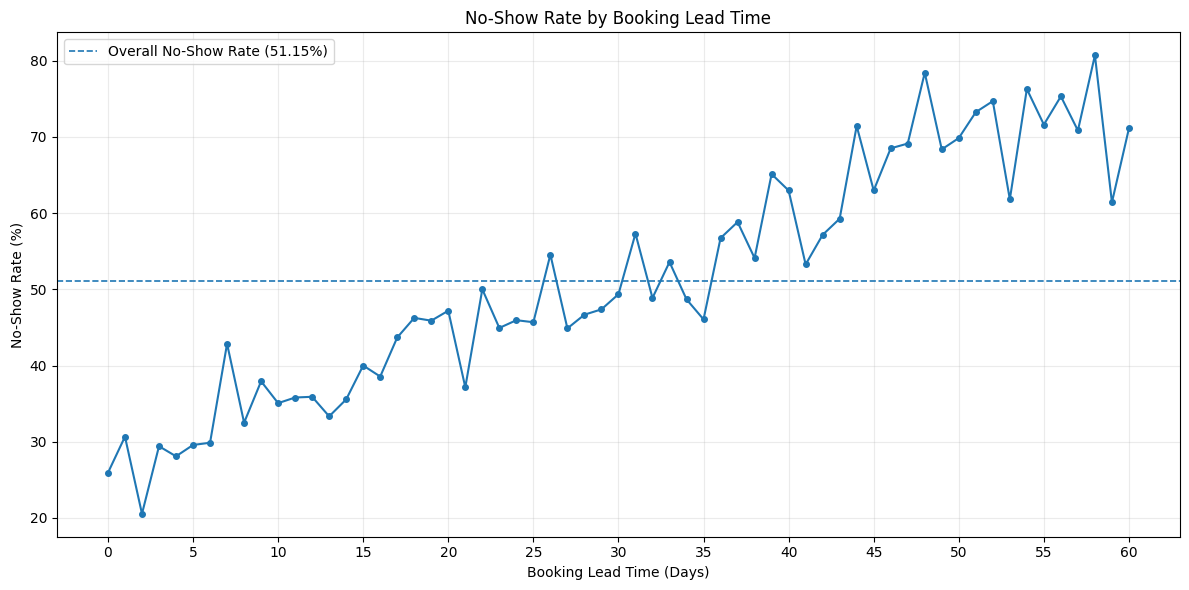

In [29]:
# H2d — Relationship between booking lead time and no-show rate

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    lead_time_rates["booking_lead_days"],
    lead_time_rates["No_Show_Rate_Percent"],
    marker="o",
    markersize=4,
    linewidth=1.5
)

# Overall no-show rate as descriptive reference
plt.axhline(
    y=no_show_rate,
    linestyle="--",
    linewidth=1.2,
    label=f"Overall No-Show Rate ({no_show_rate:.2f}%)"
)

plt.xlabel("Booking Lead Time (Days)")
plt.ylabel("No-Show Rate (%)")
plt.title("No-Show Rate by Booking Lead Time")
plt.xticks(range(0, 61, 5))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

In [30]:
# H2d — Spearman association between booking lead time and no-show outcome

from scipy.stats import spearmanr

h2d_test = h2d_data.copy()

# Binary analytical outcome:
# 0 = Attended
# 1 = No-Show
h2d_test["No_Show_Flag"] = (
    h2d_test["appointment_outcome"] == "No-Show"
).astype(int)

spearman_rho, spearman_p = spearmanr(
    h2d_test["booking_lead_days"],
    h2d_test["No_Show_Flag"]
)

print(f"Spearman's rho: {spearman_rho:.4f}")
print(f"P-value: {spearman_p:.6g}")

Spearman's rho: 0.2873
P-value: 1.08355e-90


In [31]:
# H2d — Operational booking lead-time bands

# Recalculate the overall no-show rate
overall_no_show_rate = (
    (h2d_data["appointment_outcome"] == "No-Show").sum()
    / len(h2d_data)
    * 100
)

# Define operational lead-time bands
bins = [-1, 7, 14, 30, 45, 60]

labels = [
    "0–7 days",
    "8–14 days",
    "15–30 days",
    "31–45 days",
    "46–60 days"
]

# Create a working copy
h2d_bands = h2d_data.copy()

# Assign each appointment to a lead-time band
h2d_bands["Lead_Time_Band"] = pd.cut(
    h2d_bands["booking_lead_days"],
    bins=bins,
    labels=labels
)

# Count Attended and No-Show appointments within each band
lead_band_analysis = (
    h2d_bands
    .groupby(
        ["Lead_Time_Band", "appointment_outcome"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

# Calculate analytical population
lead_band_analysis["Analytical_Population"] = (
    lead_band_analysis["Attended"]
    + lead_band_analysis["No-Show"]
)

# Calculate No-Show Rate
lead_band_analysis["No_Show_Rate_Percent"] = (
    lead_band_analysis["No-Show"]
    / lead_band_analysis["Analytical_Population"]
    * 100
)

# Calculate gap versus the overall No-Show Rate
lead_band_analysis["Gap_vs_Overall_pp"] = (
    lead_band_analysis["No_Show_Rate_Percent"]
    - overall_no_show_rate
)

# Keep relevant columns and round presentation values
lead_band_analysis = (
    lead_band_analysis[
        [
            "Attended",
            "No-Show",
            "Analytical_Population",
            "No_Show_Rate_Percent",
            "Gap_vs_Overall_pp"
        ]
    ]
    .round(2)
)

lead_band_analysis

appointment_outcome,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
Lead_Time_Band,,,,,
0–7 days,426,178,604,29.47,-21.68
8–14 days,372,202,574,35.19,-15.96
15–30 days,689,576,1265,45.53,-5.62
31–45 days,510,677,1187,57.03,5.88
46–60 days,317,790,1107,71.36,20.21


### H2d — Booking Lead Time

**Hypothesis.** No-show patterns differ according to the time between booking and the scheduled appointment.

**Population.** Non-cancelled appointments (Attended + No-Show), *n* = 4,737.

**Metric.** No-Show Rate (%), using the overall no-show rate of **51.15%** as a descriptive reference rather than a performance target.

**Evidence.** Booking lead time shows the clearest scheduling-related association with no-show observed in BQ2. No-show appointments had a higher mean booking lead time (**34.53 days**) than attended appointments (**24.52 days**), a difference of approximately **10 days**. The corresponding medians were **37 days** and **23 days**, respectively.

Analysis across the original 0–60 day values showed an overall upward pattern in no-show rates as booking lead time increased. Spearman's rank correlation confirmed a statistically significant positive association between booking lead time and no-show outcome (**ρ = 0.2873, p < 0.001**).

For operational interpretation, booking lead time was additionally grouped into analytical bands. The no-show rate increased from **29.47% for appointments booked 0–7 days in advance** to **71.36% for appointments booked 46–60 days in advance**, representing a **41.89 percentage-point difference** between the two extreme bands. The 46–60 day band was **20.21 percentage points above** the overall no-show rate.

**Finding.** Longer booking lead times are associated with substantially higher no-show rates in this dataset. Among the scheduling dimensions examined in BQ2, booking lead time provides the strongest and most decision-relevant differentiation observed so far.

**Interpretation.** Booking lead time appears to be a meaningful analytical segmentation factor for identifying appointments with comparatively higher no-show exposure. The relationship is statistically significant, although its strength is moderate and should not be interpreted as causal.

**Business Implication.** Appointments scheduled further in advance warrant closer attention when designing attendance-support interventions. In particular, later analysis should examine whether reminder strategies or other patient-engagement measures could be differentiated according to booking lead time.

> **Interpretation guardrail:** The analytical bands (0–7, 8–14, 15–30, 31–45, and 46–60 days) were created for operational interpretation. They are not predefined clinical categories or validated intervention thresholds. The observed association does not demonstrate that longer booking lead times cause no-shows.

## BQ2 — Appointment & Scheduling Context: Synthesis

**Business Question.** How do no-show patterns vary across appointment types and scheduling characteristics, including appointment day, appointment time, and booking lead time?

Four scheduling dimensions were evaluated using the non-cancelled analytical population (*n* = 4,737).

- **Appointment Type (H2a):** No-show rates ranged from **49.14% for General Consultation** to **54.17% for Follow-up appointments**. Although the chi-square test indicated statistical evidence of an association (**p = 0.0380**), the effect size was very small (**Cramér's V = 0.0422**). Appointment type therefore provides limited practical differentiation on its own.

- **Appointment Day (H2b):** No-show rates ranged from **48.71% on Friday** to **53.13% on Monday**, but differences were not statistically significant (**p = 0.3823; Cramér's V = 0.0367**). The observed day-level variation is therefore insufficient to support appointment day as a meaningful standalone discriminator of no-show.

- **Appointment Time (H2c):** No-show rates were **50.66% in the Morning, 51.19% in the Afternoon, and 52.65% in the Evening**. Differences were not statistically significant (**p = 0.6772; Cramér's V = 0.0128**), providing no meaningful evidence that appointment time alone differentiates no-show outcomes.

- **Booking Lead Time (H2d):** This dimension produced the strongest scheduling-related signal. No-show appointments had a median booking lead time of **37 days**, compared with **23 days** for attended appointments. No-show rates increased from **29.47% in the 0–7 day analytical band** to **71.36% in the 46–60 day band**, while the continuous relationship was positive and statistically significant (**Spearman's ρ = 0.2873, p < 0.001**).

### BQ2 Overall Finding

The analysis does **not** support treating all scheduling characteristics as equally informative. Appointment day and appointment time show little meaningful differentiation, while appointment type shows only a small association. In contrast, **booking lead time emerges as the most decision-relevant scheduling factor examined in BQ2**, with substantially higher no-show rates observed among appointments scheduled further in advance.

### Business Implication

From a decision-support perspective, HealthConnect should not prioritize interventions solely on appointment day or time based on the current evidence. **Booking lead time is a stronger candidate for risk segmentation and targeted attendance-support strategies.** The next analytical step should examine whether reminder exposure and reminder channel interact with observed no-show patterns, particularly among appointments booked further in advance.

> **Evidence boundary:** These results identify associations within the available observational data. They do not establish causal effects, intervention thresholds, or performance targets.

### H3a — Reminder Sent

**Hypothesis.** The no-show rate differs between appointments with and without a recorded reminder.

The analysis first distinguishes **reminder coverage** from the relationship between reminder status and appointment outcome. Reminder coverage is evaluated across all appointment records, whereas no-show comparisons exclude cancelled appointments in accordance with the defined No-Show Rate analytical population.

In [32]:
# BQ3 - H3a: Reminder Coverage Rate
# Population: all appointment records, including cancellations

total_appointments = len(df)

reminder_sent_count = (df["reminder_sent"] == "Yes").sum()
no_reminder_count = (df["reminder_sent"] == "No").sum()

reminder_coverage_rate = (
    reminder_sent_count / total_appointments * 100
)

reminder_coverage_summary = pd.DataFrame({
    "Metric": [
        "Total Appointments",
        "Reminder Sent",
        "No Reminder",
        "Reminder Coverage Rate (%)"
    ],
    "Value": [
        total_appointments,
        reminder_sent_count,
        no_reminder_count,
        round(reminder_coverage_rate, 2)
    ]
})

reminder_coverage_summary

,Metric,Value
0,Total Appointments,5000.00
1,Reminder Sent,3634.00
2,No Reminder,1366.00
3,Reminder Coverage Rate (%),72.68


In [33]:
# BQ3 - H3a: No-Show Rate by Reminder Status
# Analytical population: Attended + No-Show only
# Cancelled appointments are excluded

bq3_reminder_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

bq3_reminder_status = (
    bq3_reminder_population
    .groupby(
        ["reminder_sent", "appointment_outcome"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

bq3_reminder_status["Analytical_Population"] = (
    bq3_reminder_status["Attended"]
    + bq3_reminder_status["No-Show"]
)

bq3_reminder_status["No_Show_Rate_Percent"] = (
    bq3_reminder_status["No-Show"]
    / bq3_reminder_status["Analytical_Population"]
    * 100
)

# Overall analytical No-Show Rate
overall_nsr = (
    (bq3_reminder_population["appointment_outcome"] == "No-Show").mean()
    * 100
)

bq3_reminder_status["Gap_vs_Overall_pp"] = (
    bq3_reminder_status["No_Show_Rate_Percent"]
    - overall_nsr
)

bq3_reminder_status = (
    bq3_reminder_status
    .reset_index()
    .sort_values("No_Show_Rate_Percent", ascending=False)
)

bq3_reminder_status[
    [
        "reminder_sent",
        "Attended",
        "No-Show",
        "Analytical_Population",
        "No_Show_Rate_Percent",
        "Gap_vs_Overall_pp"
    ]
].round(2)

appointment_outcome,reminder_sent,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
0,No,583,702,1285,54.63,3.48
1,Yes,1731,1721,3452,49.86,-1.30


In [34]:
# BQ3 - H3a: Statistical test
# Reminder Sent × Appointment Outcome
# Analytical population: Attended + No-Show only

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Contingency table
bq3_reminder_contingency = pd.crosstab(
    bq3_reminder_population["reminder_sent"],
    bq3_reminder_population["appointment_outcome"]
)[["Attended", "No-Show"]]

# Chi-square test
chi2_reminder, p_reminder, dof_reminder, expected_reminder = chi2_contingency(
    bq3_reminder_contingency
)

print("Contingency table:")
display(bq3_reminder_contingency)

print(f"Chi-square statistic: {chi2_reminder:.4f}")
print(f"Degrees of freedom: {dof_reminder}")
print(f"P-value: {p_reminder:.6f}")
print(f"Minimum expected cell count: {expected_reminder.min():.2f}")

Contingency table:


appointment_outcome,Attended,No-Show
reminder_sent,,
No,583,702
Yes,1731,1721


Chi-square statistic: 8.3556
Degrees of freedom: 1
P-value: 0.003845
Minimum expected cell count: 627.72


In [35]:
# BQ3 - H3a: Effect size (Cramér's V)

n_reminder = bq3_reminder_contingency.to_numpy().sum()

cramers_v_reminder = np.sqrt(
    chi2_reminder / n_reminder
)

print(f"Analytical population: {n_reminder}")
print(f"Cramér's V: {cramers_v_reminder:.4f}")

Analytical population: 4737
Cramér's V: 0.0420


In [36]:
# BQ3 - H3a: Direct Reminder Status Gap
# Positive value = higher No-Show Rate among appointments without reminders

nsr_no_reminder = bq3_reminder_status.loc[
    bq3_reminder_status["reminder_sent"] == "No",
    "No_Show_Rate_Percent"
].iloc[0]

nsr_reminder_sent = bq3_reminder_status.loc[
    bq3_reminder_status["reminder_sent"] == "Yes",
    "No_Show_Rate_Percent"
].iloc[0]

reminder_status_gap = nsr_no_reminder - nsr_reminder_sent

print(f"No-Show Rate - No Reminder: {nsr_no_reminder:.2f}%")
print(f"No-Show Rate - Reminder Sent: {nsr_reminder_sent:.2f}%")
print(f"Reminder Status Gap: {reminder_status_gap:.2f} percentage points")

No-Show Rate - No Reminder: 54.63%
No-Show Rate - Reminder Sent: 49.86%
Reminder Status Gap: 4.78 percentage points


### H3a — Reminder Sent: Finding and Interpretation

**Hypothesis.** The no-show rate differs between appointments with and without a recorded reminder.

**Reminder Coverage.** Across all 5,000 appointment records, **3,634 (72.68%)** had a recorded reminder, while **1,366 (27.32%)** did not. This measures reminder coverage only; in the absence of a documented HealthConnect coverage target or eligibility policy, 72.68% is not interpreted as good or poor performance.

**Analytical Population.** The no-show comparison uses the **4,737 non-cancelled appointments** (Attended + No-Show), consistent with the defined No-Show Rate denominator.

**Evidence.** Appointments without a recorded reminder had a **54.63% no-show rate** (702 of 1,285), compared with **49.86%** (1,721 of 3,452) among appointments with a recorded reminder. The resulting **Reminder Status Gap is 4.78 percentage points**, with the higher no-show rate observed in the no-reminder group.

The association between reminder status and appointment outcome was statistically significant (**χ² = 8.3556, df = 1, p = 0.003845**). However, the effect size was small (**Cramér's V = 0.0420**).

**Finding.** H3a is statistically supported: no-show rates differ by recorded reminder status. However, reminder status alone provides only limited differentiation of appointment outcomes, as indicated by the small effect size.

**Interpretation.** Recorded reminder exposure is associated with a lower observed no-show rate, but the 4.78 percentage-point gap must not be interpreted as the causal effect of reminders. Reminder assignment may be related to other appointment or patient characteristics that also influence no-show patterns.

**Business Implication.** Reminder status remains relevant to attendance-support analysis, but the evidence does not justify treating reminder exposure alone as a strong predictor or claiming reminder effectiveness. Further analysis should examine whether no-show patterns differ across reminder channels and, subsequently, whether reminder-related patterns vary across other relevant appointment contexts such as booking lead time.

> **Interpretation guardrail:** Reminder Coverage Rate measures process exposure, while No-Show Rate by Reminder Status measures an observed association with appointment outcomes. Neither metric, from these observational data alone, establishes reminder effectiveness or causal impact.

### H3b — Reminder Channel

**Hypothesis.** Among appointments with a recorded reminder, the no-show rate differs across reminder channels.

**Population.** The analysis is restricted to appointments with `reminder_sent = Yes` and a non-cancelled outcome (Attended or No-Show). Appointments without a recorded reminder are excluded because their missing reminder channel is structurally not applicable rather than an unknown channel.

**Metric.** No-Show Rate (%) by reminder channel.

In [37]:
# BQ3 - H3b: No-Show Rate by Reminder Channel
# Population: reminder_sent = Yes AND outcome = Attended or No-Show

bq3_channel_population = df[
    (df["reminder_sent"] == "Yes") &
    (df["appointment_outcome"].isin(["Attended", "No-Show"]))
].copy()

# Safety check: reminder channels present in the analytical population
print(f"Analytical population: {len(bq3_channel_population)}")
print(
    "Reminder channels:",
    sorted(bq3_channel_population["reminder_channel"].dropna().unique())
)

# Cross-tabulation by reminder channel and appointment outcome
bq3_channel = (
    bq3_channel_population
    .groupby(
        ["reminder_channel", "appointment_outcome"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

bq3_channel["Analytical_Population"] = (
    bq3_channel["Attended"]
    + bq3_channel["No-Show"]
)

bq3_channel["No_Show_Rate_Percent"] = (
    bq3_channel["No-Show"]
    / bq3_channel["Analytical_Population"]
    * 100
)

# Reference: No-Show Rate among all reminded, non-cancelled appointments
reminded_nsr = (
    (bq3_channel_population["appointment_outcome"] == "No-Show").mean()
    * 100
)

bq3_channel["Gap_vs_Reminded_Overall_pp"] = (
    bq3_channel["No_Show_Rate_Percent"]
    - reminded_nsr
)

bq3_channel = (
    bq3_channel
    .reset_index()
    .sort_values("No_Show_Rate_Percent", ascending=False)
)

print(f"\nOverall No-Show Rate among reminded appointments: {reminded_nsr:.2f}%")

display(
    bq3_channel[
        [
            "reminder_channel",
            "Attended",
            "No-Show",
            "Analytical_Population",
            "No_Show_Rate_Percent",
            "Gap_vs_Reminded_Overall_pp"
        ]
    ].round(2)
)

Analytical population: 3452
Reminder channels: ['Email', 'SMS', 'WhatsApp']

Overall No-Show Rate among reminded appointments: 49.86%


appointment_outcome,reminder_channel,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Reminded_Overall_pp
2,WhatsApp,491,548,1039,52.74,2.89
0,Email,248,258,506,50.99,1.13
1,SMS,992,915,1907,47.98,-1.87


In [38]:
# BQ3 - H3b: Statistical test
# Reminder Channel × Appointment Outcome
# Population: reminded + non-cancelled appointments only

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

bq3_channel_contingency = pd.crosstab(
    bq3_channel_population["reminder_channel"],
    bq3_channel_population["appointment_outcome"]
)[["Attended", "No-Show"]]

chi2_channel, p_channel, dof_channel, expected_channel = chi2_contingency(
    bq3_channel_contingency
)

print("Contingency table:")
display(bq3_channel_contingency)

print(f"Chi-square statistic: {chi2_channel:.4f}")
print(f"Degrees of freedom: {dof_channel}")
print(f"P-value: {p_channel:.6f}")
print(f"Minimum expected cell count: {expected_channel.min():.2f}")

Contingency table:


appointment_outcome,Attended,No-Show
reminder_channel,,
Email,248,258
SMS,992,915
WhatsApp,491,548


Chi-square statistic: 6.4048
Degrees of freedom: 2
P-value: 0.040664
Minimum expected cell count: 252.27


In [39]:
# BQ3 - H3b: Effect size using Cramér's V

n_channel = bq3_channel_contingency.to_numpy().sum()

cramers_v_channel = np.sqrt(
    chi2_channel /
    (n_channel * min(bq3_channel_contingency.shape[0] - 1,
                     bq3_channel_contingency.shape[1] - 1))
)

print(f"Analytical population: {n_channel}")
print(f"Cramér's V: {cramers_v_channel:.4f}")

Analytical population: 3452
Cramér's V: 0.0431


### H3b — Reminder Channel

**Business Question:** How do no-show patterns vary by reminder channel among appointments with a recorded reminder?

**Hypothesis:** The no-show rate differs across reminder channels.

**Population:** Appointments with `reminder_sent = Yes`, excluding cancelled appointments from the no-show rate denominator (N = 3,452).

**Metric:** No-Show Rate (%) by reminder channel.

**Evidence:**
- SMS: 47.98% no-show rate (915 / 1,907)
- Email: 50.99% (258 / 506)
- WhatsApp: 52.74% (548 / 1,039)
- Overall no-show rate among reminded appointments: 49.86%
- Maximum observed channel gap: 4.76 percentage points (WhatsApp vs SMS)
- Chi-square test: χ² = 6.4048, df = 2, p = 0.0407
- Cramér's V = 0.0431

**Finding:** No-show rates vary modestly across reminder channels. SMS records the lowest observed no-show rate, while WhatsApp records the highest. The association between reminder channel and appointment outcome is statistically significant at the 5% level, but the effect size is very small.

**Interpretation:** Reminder channel is associated with appointment outcome in this dataset, but channel alone explains little of the observed variation in attendance behaviour. Statistical significance should therefore not be interpreted as strong practical importance.

**Business Implication:** Reminder channel may be worth considering as one component of reminder strategy, but the evidence does not justify prioritising a channel solely on the basis of these unadjusted comparisons. Other factors may influence both channel assignment and appointment attendance.

**Analytical Guardrail:** These observational results establish association, not causal effectiveness. SMS cannot be described as more effective than Email or WhatsApp without stronger evidence or an appropriate controlled evaluation.

## BQ3 — Reminder & Engagement: Decision-Oriented Synthesis

**Business Question:** How do no-show patterns vary by reminder status and, where applicable, reminder channel?

The reminder analysis reveals three distinct dimensions that should not be conflated: **reminder coverage, observed association with no-show, and causal effectiveness**.

### Key Evidence

- **Reminder Coverage Rate:** 72.68% of all 5,000 appointment records had a recorded reminder.
- Among non-cancelled appointments, the **No-Show Rate was 54.63% without a reminder versus 49.86% with a reminder**, representing an observed gap of **4.78 percentage points**.
- Reminder status was statistically associated with appointment outcome (χ² = 8.3556, p = 0.0038), but the association was **very weak** (Cramér's V = 0.0420).
- Among reminded, non-cancelled appointments, No-Show Rates varied by channel:
  - SMS: 47.98%
  - Email: 50.99%
  - WhatsApp: 52.74%
- The maximum observed channel gap was **4.76 percentage points** between WhatsApp and SMS.
- Reminder channel was also statistically associated with appointment outcome (χ² = 6.4048, p = 0.0407), but again with a **very small effect size** (Cramér's V = 0.0431).

### Finding

Appointments with a recorded reminder show a moderately lower observed No-Show Rate than appointments without one. Differences are also observed across reminder channels, with SMS recording the lowest No-Show Rate among reminded appointments. However, both statistical associations have very small effect sizes.

### Interpretation

Reminder-related variables provide a detectable but limited signal for explaining appointment attendance patterns. The observed differences do not establish that reminders themselves — or a particular reminder channel — caused the differences in no-show behaviour.

### Business Implication

Reminder strategy remains relevant to appointment management, but the evidence does not support treating reminder delivery or channel selection as a standalone solution to the no-show problem. Further analysis should examine whether reminder patterns interact with stronger contextual factors such as booking lead time, accessibility, operational conditions, appointment characteristics, or recorded patient history.

### Decision Guardrail

**Coverage ≠ Effectiveness. Association ≠ Causality.**

No recommendation to increase reminder coverage, change reminder channels, or prioritise SMS should be made solely from these unadjusted comparisons. A stronger evaluation design or additional multivariable analysis would be required before making causal claims about reminder effectiveness.

### H4a — Distance to Clinic

**Business Question:** How do no-show patterns vary across recorded distance-to-clinic levels?

**Hypothesis H4a:** No-show patterns differ according to recorded distance to the clinic.

**Analytical population:** Non-cancelled appointments (`Attended` and `No-Show`) with a non-missing value for `distance_to_clinic_km`.

**Primary analytical variable:** `distance_to_clinic_km`

**Outcome:** `appointment_outcome`

**Analytical approach:**
1. Quantify the usable analytical population and missing-distance records.
2. Compare the distribution of recorded distance between Attended and No-Show appointments.
3. Evaluate whether a meaningful relationship exists between distance and appointment outcome.
4. Examine the shape of the relationship before considering any distance bands.
5. If grouping is subsequently used, bands will be analytically justified rather than selected solely for convenience.

**Interpretation guardrail:**  
Observed differences in distance are associations and do not establish that greater distance causes a patient to miss an appointment. Missing distance values will not be imputed without a defensible basis.

In [40]:
# H4a — Distance to Clinic
# Build the variable-specific analytical population

h4a_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

total_non_cancelled = len(h4a_population)

missing_distance = h4a_population["distance_to_clinic_km"].isna().sum()

h4a_complete = h4a_population.dropna(
    subset=["distance_to_clinic_km"]
).copy()

usable_distance = len(h4a_complete)

print(f"Non-cancelled appointments: {total_non_cancelled}")
print(f"Missing distance values: {missing_distance}")
print(f"Usable H4a analytical population: {usable_distance}")
print(
    f"Distance completeness within analytical population: "
    f"{usable_distance / total_non_cancelled * 100:.2f}%"
)

Non-cancelled appointments: 4737
Missing distance values: 86
Usable H4a analytical population: 4651
Distance completeness within analytical population: 98.18%


In [41]:
# Descriptive comparison of distance by appointment outcome

distance_summary = (
    h4a_complete
    .groupby("appointment_outcome")["distance_to_clinic_km"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
    .round(2)
)

distance_summary

,Count,Mean,Median,Std,Min,Max
appointment_outcome,,,,,,
Attended,2275,9.67,8.3,6.22,0.5,45.0
No-Show,2376,10.53,9.1,6.94,0.5,45.0


In [42]:
# H4a — Association between distance to clinic and appointment outcome
# Spearman correlation on the complete non-cancelled analytical population

from scipy.stats import spearmanr

# Binary outcome for association testing:
# Attended = 0, No-Show = 1
h4a_complete = h4a_complete.copy()

h4a_complete["no_show_flag"] = (
    h4a_complete["appointment_outcome"]
    .map({"Attended": 0, "No-Show": 1})
)

rho_distance, p_distance = spearmanr(
    h4a_complete["distance_to_clinic_km"],
    h4a_complete["no_show_flag"]
)

print(f"Analytical population: {len(h4a_complete)}")
print(f"Spearman's rho: {rho_distance:.4f}")
print(f"P-value: {p_distance:.6g}")

Analytical population: 4651
Spearman's rho: 0.0551
P-value: 0.000170738


In [43]:
# H4a — No-show pattern across recorded distance to clinic
# Use 1-km intervals for exploratory visualization only

distance_pattern = h4a_complete.copy()

distance_pattern["Distance_KM_Rounded"] = (
    distance_pattern["distance_to_clinic_km"].round()
)

distance_rate = (
    distance_pattern
    .groupby("Distance_KM_Rounded")["no_show_flag"]
    .agg(["count", "mean"])
    .reset_index()
)

distance_rate["No_Show_Rate_Percent"] = (
    distance_rate["mean"] * 100
).round(2)

distance_rate = distance_rate.rename(
    columns={"count": "Analytical_Population"}
)

distance_rate[
    [
        "Distance_KM_Rounded",
        "Analytical_Population",
        "No_Show_Rate_Percent"
    ]
].head(15)

,Distance_KM_Rounded,Analytical_Population,No_Show_Rate_Percent
0,0.0,12,66.67
1,1.0,81,54.32
2,2.0,225,50.22
3,3.0,247,48.99
4,4.0,345,45.51
5,5.0,325,48.00
6,6.0,388,46.91
7,7.0,291,48.45
8,8.0,375,52.53
9,9.0,252,48.41


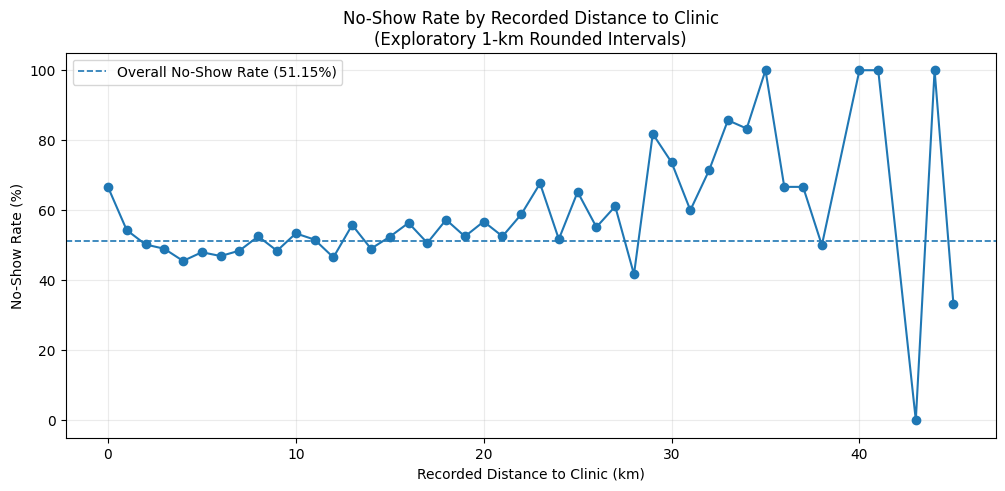

In [44]:
# H4a — Exploratory no-show pattern by recorded distance
# Rounded kilometres are used for exploration only, not as business segments.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    distance_rate["Distance_KM_Rounded"],
    distance_rate["No_Show_Rate_Percent"],
    marker="o",
    linewidth=1.5
)

ax.axhline(
    y=overall_no_show_rate,
    linestyle="--",
    linewidth=1.2,
    label=f"Overall No-Show Rate ({overall_no_show_rate:.2f}%)"
)

ax.set_title(
    "No-Show Rate by Recorded Distance to Clinic\n"
    "(Exploratory 1-km Rounded Intervals)"
)
ax.set_xlabel("Recorded Distance to Clinic (km)")
ax.set_ylabel("No-Show Rate (%)")
ax.legend()
ax.grid(alpha=0.25)

plt.show()

In [45]:
# H4a — Observation volume by rounded distance
# Used to assess the reliability of the exploratory no-show rates

distance_volume = (
    distance_rate[
        [
            "Distance_KM_Rounded",
            "Analytical_Population",
            "No_Show_Rate_Percent"
        ]
    ]
    .sort_values("Distance_KM_Rounded")
    .reset_index(drop=True)
)

distance_volume

,Distance_KM_Rounded,Analytical_Population,No_Show_Rate_Percent
0,0.0,12,66.67
1,1.0,81,54.32
2,2.0,225,50.22
3,3.0,247,48.99
4,4.0,345,45.51
5,5.0,325,48.00
6,6.0,388,46.91
7,7.0,291,48.45
8,8.0,375,52.53
9,9.0,252,48.41


In [46]:
# H4a — Identify low-volume distance intervals

volume_threshold = 30

low_volume_distance = distance_volume[
    distance_volume["Analytical_Population"] < volume_threshold
]

print(
    f"Rounded-distance intervals with fewer than "
    f"{volume_threshold} appointments: "
    f"{len(low_volume_distance)}"
)

low_volume_distance

Rounded-distance intervals with fewer than 30 appointments: 21


,Distance_KM_Rounded,Analytical_Population,No_Show_Rate_Percent
0,0.0,12,66.67
24,24.0,29,51.72
25,25.0,23,65.22
26,26.0,29,55.17
27,27.0,18,61.11
28,28.0,12,41.67
29,29.0,11,81.82
30,30.0,19,73.68
31,31.0,10,60.00
32,32.0,7,71.43


In [47]:
# H4a — Descriptive distance bands
# Bands are used to stabilise descriptive rates and improve interpretability.
# They are NOT validated risk thresholds.

distance_band_data = h4a_complete.copy()

distance_band_data["Distance_Band"] = pd.cut(
    distance_band_data["distance_to_clinic_km"],
    bins=[0, 5, 10, 20, 30, float("inf")],
    labels=[
        "0–5 km",
        ">5–10 km",
        ">10–20 km",
        ">20–30 km",
        ">30 km"
    ],
    include_lowest=True,
    right=True
)

distance_band_analysis = (
    pd.crosstab(
        distance_band_data["Distance_Band"],
        distance_band_data["appointment_outcome"]
    )
    .reindex(columns=["Attended", "No-Show"], fill_value=0)
)

distance_band_analysis["Analytical_Population"] = (
    distance_band_analysis["Attended"]
    + distance_band_analysis["No-Show"]
)

distance_band_analysis["No_Show_Rate_Percent"] = (
    distance_band_analysis["No-Show"]
    / distance_band_analysis["Analytical_Population"]
    * 100
)

distance_band_analysis["Gap_vs_Overall_pp"] = (
    distance_band_analysis["No_Show_Rate_Percent"]
    - overall_no_show_rate
)

distance_band_analysis[
    [
        "Attended",
        "No-Show",
        "Analytical_Population",
        "No_Show_Rate_Percent",
        "Gap_vs_Overall_pp"
    ]
].round(2)

appointment_outcome,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
Distance_Band,,,,,
0–5 km,566,537,1103,48.69,-2.47
>5–10 km,808,787,1595,49.34,-1.81
>10–20 km,753,825,1578,52.28,1.13
>20–30 km,127,178,305,58.36,7.21
>30 km,21,49,70,70.00,18.85


### H4a — Distance to Clinic: Findings and Business Interpretation

**Business Question:** How do no-show patterns vary across recorded distance-to-clinic levels?

**Hypothesis:** No-show patterns differ according to recorded distance to the clinic.

**Analytical Population:** 4,651 non-cancelled appointments with a recorded `distance_to_clinic_km` value. Of the 4,737 non-cancelled appointments, 86 (1.82%) had missing distance information and were excluded from this variable-specific analysis.

**Metric:** No-Show Rate (%) across recorded distance to clinic.

### Evidence

- Mean recorded distance:
  - Attended: **9.67 km**
  - No-Show: **10.53 km**
  - Mean difference: **+0.86 km** for No-Show appointments.
- Median recorded distance:
  - Attended: **8.3 km**
  - No-Show: **9.1 km**
  - Median difference: **+0.8 km**.
- Spearman's rho = **0.0551**, p = **0.00017**, indicating a statistically significant but **very weak positive association** between recorded distance and no-show outcome.
- Exploratory 1-km rates became highly volatile at longer distances because of small observation counts.
- In broader descriptive bands, the observed No-Show Rate increased from:
  - **48.69%** at 0–5 km
  - **49.34%** at >5–10 km
  - **52.28%** at >10–20 km
  - **58.36%** at >20–30 km
  - **70.00%** at >30 km.
- The >30 km band contains only **70 appointments**, so its observed rate should be interpreted cautiously.

### Finding

Appointments with a No-Show outcome have slightly greater recorded distances on average and at the median than attended appointments. Aggregated distance bands show progressively higher observed No-Show Rates at greater distances. However, the overall continuous association is very weak, and estimates at the longest distances are based on substantially smaller populations.

### Interpretation

Recorded distance appears to be associated with appointment attendance, but distance alone has limited discriminatory strength. The stronger rates observed at longer distances warrant further investigation, particularly because sparse observations make estimates in the upper distance range less stable.

### Business Implication

Accessibility may contribute to appointment attendance challenges for some patients, particularly those recorded farther from the clinic. However, the current evidence does not justify defining a fixed distance-based risk threshold or treating distance as a standalone predictor. Distance should instead be considered alongside other scheduling, operational, reminder, and patient-context variables when identifying potentially vulnerable appointment contexts.

### Analytical Guardrail

The distance bands are **descriptive analytical groupings, not validated risk thresholds**. The overall No-Show Rate is used as a descriptive reference, not as a performance benchmark or target. Observed associations do not establish that greater distance causes No-Shows.

### H4b — Waiting Time

**Business Question:** How do no-show patterns vary across recorded estimated waiting-time levels?

**Hypothesis H4b:** No-show patterns differ according to recorded `waiting_time_minutes`.

**Analytical approach:** The analysis is restricted to non-cancelled appointments (`Attended` and `No-Show`). Because `waiting_time_minutes` contains missing values, the usable analytical population is established before comparing outcomes.

Waiting time is first analysed as a continuous variable. Descriptive statistics and the distribution of waiting time across appointment outcomes are examined before considering any grouped representation. Any grouping introduced later will be used for descriptive interpretability and will not automatically constitute a validated operational threshold.

**Interpretation guardrail:** Observed associations between recorded waiting time and appointment outcome do not establish that waiting time causes No-Shows.

In [48]:
# H4b — Define analytical population for waiting-time analysis

h4b_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

h4b_missing_waiting = h4b_population["waiting_time_minutes"].isna().sum()

h4b_complete = h4b_population.dropna(
    subset=["waiting_time_minutes"]
).copy()

print(f"Non-cancelled appointments: {len(h4b_population)}")
print(f"Missing waiting-time values: {h4b_missing_waiting}")
print(f"Usable H4b analytical population: {len(h4b_complete)}")
print(
    f"Waiting-time completeness within analytical population: "
    f"{len(h4b_complete) / len(h4b_population) * 100:.2f}%"
)

Non-cancelled appointments: 4737
Missing waiting-time values: 58
Usable H4b analytical population: 4679
Waiting-time completeness within analytical population: 98.78%


In [49]:
# H4b — Descriptive comparison of waiting time:
# Attended vs No-Show

waiting_summary = (
    h4b_complete
    .groupby("appointment_outcome")["waiting_time_minutes"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
    .round(2)
)

waiting_summary

,Count,Mean,Median,Std,Min,Max
appointment_outcome,,,,,,
Attended,2293,24.29,24.0,10.95,2.0,68.0
No-Show,2386,24.20,24.0,10.81,2.0,67.0


In [50]:
# H4b — Test association between waiting time and no-show outcome

from scipy.stats import spearmanr

# Binary outcome: 1 = No-Show, 0 = Attended
h4b_complete["No_Show_Flag"] = (
    h4b_complete["appointment_outcome"] == "No-Show"
).astype(int)

spearman_waiting = spearmanr(
    h4b_complete["waiting_time_minutes"],
    h4b_complete["No_Show_Flag"]
)

print(f"Analytical population: {len(h4b_complete)}")
print(f"Spearman's rho: {spearman_waiting.statistic:.4f}")
print(f"P-value: {spearman_waiting.pvalue:.6f}")

Analytical population: 4679
Spearman's rho: -0.0040
P-value: 0.785909


In [51]:
# H4b — Exploratory no-show rate by recorded waiting time

waiting_rate = (
    h4b_complete
    .groupby("waiting_time_minutes")["No_Show_Flag"]
    .agg(
        Analytical_Population="count",
        No_Show_Rate_Percent="mean"
    )
    .reset_index()
)

waiting_rate["No_Show_Rate_Percent"] = (
    waiting_rate["No_Show_Rate_Percent"] * 100
).round(2)

waiting_rate

,waiting_time_minutes,Analytical_Population,No_Show_Rate_Percent
0,2.0,130,51.54
1,3.0,29,48.28
2,4.0,19,42.11
3,5.0,41,60.98
4,6.0,36,50.00
...,...,...,...
57,59.0,1,0.00
58,60.0,1,0.00
59,64.0,1,100.00
60,67.0,1,100.00


In [52]:
# H4b — Identify low-volume waiting-time values

waiting_volume = (
    waiting_rate
    .sort_values("waiting_time_minutes")
    .copy()
)

low_volume_waiting = waiting_volume[
    waiting_volume["Analytical_Population"] < 30
]

print(
    f"Waiting-time values with fewer than 30 appointments: "
    f"{len(low_volume_waiting)}"
)

low_volume_waiting

Waiting-time values with fewer than 30 appointments: 21


,waiting_time_minutes,Analytical_Population,No_Show_Rate_Percent
1,3.0,29,48.28
2,4.0,19,42.11
43,45.0,27,51.85
44,46.0,15,46.67
45,47.0,25,52.00
46,48.0,13,38.46
47,49.0,17,52.94
48,50.0,9,77.78
49,51.0,8,62.50
50,52.0,8,50.00


#### H4b — Waiting Time

Recorded waiting time does not show a meaningful relationship with appointment no-show in the available data. Among 4,679 non-cancelled appointments with recorded waiting-time information, attended and no-show appointments have nearly identical waiting-time distributions: mean waiting times are 24.29 and 24.20 minutes respectively, with a median of 24 minutes in both groups.

The Spearman correlation between recorded waiting time and no-show status is effectively zero (ρ = -0.0040, p = 0.7859), providing no evidence of a statistically significant monotonic association.

Exploratory rates by individual waiting-time values become unstable at sparsely represented values: 21 of the 62 observed waiting-time values contain fewer than 30 appointments. These extreme rates should therefore not be interpreted as evidence of a systematic waiting-time effect.

**Decision implication:** Based on the available evidence, recorded waiting time does not currently emerge as a useful discriminator for identifying appointments at higher risk of no-show. It should therefore not be prioritised as a standalone no-show targeting factor without additional evidence.

### BQ4 — Accessibility & Operational Context: Decision Summary

Accessibility and operational variables provide different levels of analytical signal.

- **Distance to clinic:** No-show rates tend to increase with recorded distance, but the overall association is weak and estimates at longer distances are based on substantially smaller populations. Distance may therefore warrant further investigation, but the available evidence does not support treating it as a strong standalone predictor.
- **Waiting time:** No meaningful association with no-show status was detected. Attended and no-show appointments show nearly identical waiting-time distributions, and the statistical association is effectively null.

**Overall decision implication:** The evidence does not support treating accessibility and operational context as a single homogeneous risk dimension. Recorded distance provides a limited signal that may complement stronger factors, whereas recorded waiting time does not currently provide useful discrimination for no-show risk.

## BQ5 — Recorded Patient History

**Business Question:** How do no-show patterns vary according to recorded previous appointments and previous no-shows?

### H5a — Previous Appointments

**Hypothesis:** No-show patterns differ according to the recorded number of previous appointments.

This analysis evaluates whether the recorded level of previous appointment history is associated with appointment outcome. `previous_appointments` is interpreted as a record-level historical attribute and not as a reconstructed longitudinal patient history.

Cancelled appointments are excluded from the no-show analytical population.

In [53]:
# H5a — Recorded previous appointments
# Define analytical population and compare Attended vs No-Show

h5a_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

h5a_missing = h5a_population["previous_appointments"].isna().sum()

h5a_complete = h5a_population.dropna(
    subset=["previous_appointments"]
).copy()

print(f"Non-cancelled appointments: {len(h5a_population)}")
print(f"Missing previous_appointments values: {h5a_missing}")
print(f"Usable H5a analytical population: {len(h5a_complete)}")
print(
    "Previous-appointments completeness within analytical population: "
    f"{len(h5a_complete) / len(h5a_population) * 100:.2f}%"
)

previous_appointments_summary = (
    h5a_complete
    .groupby("appointment_outcome")["previous_appointments"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

previous_appointments_summary

Non-cancelled appointments: 4737
Missing previous_appointments values: 0
Usable H5a analytical population: 4737
Previous-appointments completeness within analytical population: 100.00%


,count,mean,median,std,min,max
appointment_outcome,,,,,,
Attended,2314,2.95,3.0,1.72,0,10
No-Show,2423,3.10,3.0,1.76,0,11


In [54]:
# H5a — No-show rate by recorded number of previous appointments

h5a_complete["No_Show_Flag"] = (
    h5a_complete["appointment_outcome"] == "No-Show"
).astype(int)

previous_appointments_rate = (
    h5a_complete
    .groupby("previous_appointments")
    .agg(
        Attended=("appointment_outcome",
                  lambda x: (x == "Attended").sum()),
        No_Show=("appointment_outcome",
                 lambda x: (x == "No-Show").sum()),
        Analytical_Population=("appointment_outcome", "size"),
        No_Show_Rate_Percent=("No_Show_Flag", "mean")
    )
    .reset_index()
)

previous_appointments_rate["No_Show_Rate_Percent"] = (
    previous_appointments_rate["No_Show_Rate_Percent"] * 100
).round(2)

previous_appointments_rate["Gap_vs_Overall_pp"] = (
    previous_appointments_rate["No_Show_Rate_Percent"] - 51.15
).round(2)

previous_appointments_rate

,previous_appointments,Attended,No_Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
0,0,124,104,228,45.61,-5.54
1,1,362,344,706,48.73,-2.42
2,2,534,525,1059,49.58,-1.57
3,3,483,557,1040,53.56,2.41
4,4,407,412,819,50.31,-0.84
5,5,219,252,471,53.50,2.35
6,6,105,127,232,54.74,3.59
7,7,59,62,121,51.24,0.09
8,8,14,31,45,68.89,17.74
9,9,6,7,13,53.85,2.70


In [55]:
# H5a — Test monotonic association between recorded
# previous appointments and no-show status

from scipy.stats import spearmanr

spearman_previous_appointments = spearmanr(
    h5a_complete["previous_appointments"],
    h5a_complete["No_Show_Flag"]
)

print(f"Analytical population: {len(h5a_complete)}")
print(
    "Spearman's rho: "
    f"{spearman_previous_appointments.statistic:.4f}"
)
print(
    "P-value: "
    f"{spearman_previous_appointments.pvalue:.6f}"
)

Analytical population: 4737
Spearman's rho: 0.0400
P-value: 0.005917


#### H5a — Previous Appointments: Finding & Interpretation

Among 4,737 non-cancelled appointments, recorded previous appointment history is complete. No-show appointments show a slightly higher mean number of previous appointments than attended appointments (3.10 vs 2.95), while both groups have the same median of 3.

No-show rates vary across recorded previous-appointment levels, but the pattern is not consistently monotonic. A Spearman test identifies a statistically significant positive association between `previous_appointments` and no-show status (ρ = 0.0400, p = 0.0059); however, the effect size is extremely small.

Rates at the highest history levels should also be interpreted cautiously because the underlying populations become sparse.

**Finding:** Recorded previous appointment count is statistically associated with no-show status, but the observed relationship is very weak and does not provide strong standalone discrimination.

**Business implication:** Previous appointment count may provide limited contextual information when combined with stronger attendance-risk signals, but the available evidence does not support prioritising it as a standalone targeting factor.

### H5b — Previous No-Shows

**Hypothesis:** No-show patterns differ according to the recorded number of previous no-shows.

This analysis evaluates whether recorded previous no-show history is associated with the current appointment outcome. `previous_no_shows` is treated as a record-level historical attribute rather than as a reconstructed longitudinal patient history.

Cancelled appointments are excluded from the no-show analytical population.

In [56]:
# H5b — Recorded previous no-shows
# Define analytical population and compare Attended vs No-Show

h5b_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

h5b_missing = h5b_population["previous_no_shows"].isna().sum()

h5b_complete = h5b_population.dropna(
    subset=["previous_no_shows"]
).copy()

print(f"Non-cancelled appointments: {len(h5b_population)}")
print(f"Missing previous_no_shows values: {h5b_missing}")
print(f"Usable H5b analytical population: {len(h5b_complete)}")
print(
    "Previous-no-shows completeness within analytical population: "
    f"{len(h5b_complete) / len(h5b_population) * 100:.2f}%"
)

previous_no_shows_summary = (
    h5b_complete
    .groupby("appointment_outcome")["previous_no_shows"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
    .round(2)
)

previous_no_shows_summary

Non-cancelled appointments: 4737
Missing previous_no_shows values: 0
Usable H5b analytical population: 4737
Previous-no-shows completeness within analytical population: 100.00%


,Count,Mean,Median,Std,Min,Max
appointment_outcome,,,,,,
Attended,2314,0.46,0.0,0.68,0,4
No-Show,2423,0.64,0.0,0.80,0,5


In [57]:
# H5b — No-show rate by recorded number of previous no-shows

h5b_complete["No_Show_Flag"] = (
    h5b_complete["appointment_outcome"] == "No-Show"
).astype(int)

previous_no_shows_rate = (
    h5b_complete
    .groupby("previous_no_shows")
    .agg(
        Attended=(
            "appointment_outcome",
            lambda x: (x == "Attended").sum()
        ),
        No_Show=(
            "appointment_outcome",
            lambda x: (x == "No-Show").sum()
        ),
        Analytical_Population=("appointment_outcome", "size"),
        No_Show_Rate_Percent=("No_Show_Flag", "mean")
    )
    .reset_index()
)

previous_no_shows_rate["No_Show_Rate_Percent"] = (
    previous_no_shows_rate["No_Show_Rate_Percent"] * 100
).round(2)

previous_no_shows_rate["Gap_vs_Overall_pp"] = (
    previous_no_shows_rate["No_Show_Rate_Percent"] - 51.15
).round(2)

previous_no_shows_rate

,previous_no_shows,Attended,No_Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
0,0,1474,1271,2745,46.30,-4.85
1,1,654,828,1482,55.87,4.72
2,2,159,260,419,62.05,10.90
3,3,23,53,76,69.74,18.59
4,4,4,8,12,66.67,15.52
5,5,0,3,3,100.00,48.85


In [58]:
# H5b — Test monotonic association between recorded
# previous no-shows and current no-show status

from scipy.stats import spearmanr

spearman_previous_no_shows = spearmanr(
    h5b_complete["previous_no_shows"],
    h5b_complete["No_Show_Flag"]
)

print(f"Analytical population: {len(h5b_complete)}")
print(
    "Spearman's rho: "
    f"{spearman_previous_no_shows.statistic:.4f}"
)
print(
    "P-value: "
    f"{spearman_previous_no_shows.pvalue:.6g}"
)

Analytical population: 4737
Spearman's rho: 0.1214
P-value: 5.20691e-17


#### H5b — Previous No-Shows: Finding & Interpretation

Among 4,737 non-cancelled appointments, `previous_no_shows` is complete. No-show appointments have a higher mean recorded number of previous no-shows than attended appointments (0.64 vs 0.46), although the median is 0 for both groups.

A clear descriptive gradient is observed across the sufficiently represented history levels. The no-show rate increases from 46.30% for appointments with no recorded previous no-show to 55.87% with one, 62.05% with two, and 69.74% with three. This represents a 23.44 percentage-point difference between 0 and 3 recorded previous no-shows.

Spearman's correlation confirms a statistically significant positive association between recorded previous no-shows and current no-show status (ρ = 0.1214, p < 0.001). However, the effect size remains weak. Levels 4 and 5 should not be interpreted independently because their analytical populations are very small (n = 12 and n = 3).

**Finding:** A higher recorded previous no-show count is associated with a higher current no-show rate, with a clearer and stronger pattern than observed for the total number of previous appointments.

**Business implication:** Recorded previous no-show history may provide useful information for identifying appointments that warrant additional attendance-support attention. It should be considered alongside other relevant signals rather than used as a standalone targeting criterion.

**Interpretation guardrail:** This is an observational association based on a record-level historical variable. It does not establish that previous no-shows cause future no-shows, and the patient-level consistency limitations identified during data-quality validation remain applicable.

### BQ5 — Recorded Patient History: Decision Summary

The two recorded history variables do not provide the same level of decision-support value.

`previous_appointments` shows only an extremely weak association with current no-show status (ρ = 0.0400), despite statistical significance. In contrast, `previous_no_shows` shows a clearer descriptive gradient and a stronger, although still weak, positive association (ρ = 0.1214).

**Decision-support implication:** If recorded appointment history is incorporated into future attendance-support prioritisation, previous no-show history appears more informative than the total number of previous appointments. It should nevertheless be combined with other validated factors rather than treated as a standalone decision rule.

## BQ6 — Recorded Patient Characteristics

**Business Question:** How do no-show patterns vary across recorded age groups and gender categories?

### H6a — Age Group

**Hypothesis:** No-show rates differ across recorded age groups.

This analysis compares current appointment outcomes across the recorded `age_group` categories. Cancelled appointments are excluded from the no-show analytical population.

Because patient-level demographic inconsistencies were identified during data-quality validation, `age_group` is interpreted strictly as a characteristic recorded on each appointment record. The analysis does not reconstruct or infer a patient's longitudinal demographic history.

In [59]:
# H6a — Age Group
# Define analytical population and compare Attended vs No-Show

h6a_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

h6a_missing = h6a_population["age_group"].isna().sum()

h6a_complete = h6a_population.dropna(
    subset=["age_group"]
).copy()

print(f"Non-cancelled appointments: {len(h6a_population)}")
print(f"Missing age_group values: {h6a_missing}")
print(f"Usable H6a analytical population: {len(h6a_complete)}")
print(
    "Age-group completeness within analytical population: "
    f"{len(h6a_complete) / len(h6a_population) * 100:.2f}%"
)

age_group_summary = pd.crosstab(
    h6a_complete["age_group"],
    h6a_complete["appointment_outcome"]
)

# Preserve the natural age-group order
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

age_group_summary = age_group_summary.reindex(age_order)

age_group_summary

Non-cancelled appointments: 4737
Missing age_group values: 0
Usable H6a analytical population: 4737
Age-group completeness within analytical population: 100.00%


appointment_outcome,Attended,No-Show
age_group,,
18-24,257,283
25-34,353,397
35-44,374,396
45-54,365,381
55-64,360,406
65+,605,560


In [60]:
# H6a — No-show rate by recorded age group

overall_no_show_rate = (
    (df["appointment_outcome"] == "No-Show").sum()
    / df["appointment_outcome"].isin(["Attended", "No-Show"]).sum()
    * 100
)

age_group_rate = (
    pd.crosstab(
        h6a_complete["age_group"],
        h6a_complete["appointment_outcome"]
    )
    .reindex(age_order)
)

age_group_rate["Analytical_Population"] = (
    age_group_rate["Attended"] + age_group_rate["No-Show"]
)

age_group_rate["No_Show_Rate_Percent"] = (
    age_group_rate["No-Show"]
    / age_group_rate["Analytical_Population"]
    * 100
)

age_group_rate["Gap_vs_Overall_pp"] = (
    age_group_rate["No_Show_Rate_Percent"]
    - overall_no_show_rate
)

age_group_rate = age_group_rate[
    [
        "Attended",
        "No-Show",
        "Analytical_Population",
        "No_Show_Rate_Percent",
        "Gap_vs_Overall_pp"
    ]
].round(2)

age_group_rate

appointment_outcome,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
age_group,,,,,
18-24,257,283,540,52.41,1.26
25-34,353,397,750,52.93,1.78
35-44,374,396,770,51.43,0.28
45-54,365,381,746,51.07,-0.08
55-64,360,406,766,53.00,1.85
65+,605,560,1165,48.07,-3.08


In [61]:
# H6a — Chi-square test and Cramér's V
# Association between recorded age group and appointment outcome

from scipy.stats import chi2_contingency
import numpy as np

age_group_contingency = pd.crosstab(
    h6a_complete["age_group"],
    h6a_complete["appointment_outcome"]
).reindex(age_order)

chi2_age, p_age, dof_age, expected_age = chi2_contingency(
    age_group_contingency
)

n_age = age_group_contingency.to_numpy().sum()
r_age, k_age = age_group_contingency.shape

cramers_v_age = np.sqrt(
    chi2_age / (n_age * min(r_age - 1, k_age - 1))
)

print("Contingency table:")
display(age_group_contingency)

print(f"\nChi-square statistic: {chi2_age:.4f}")
print(f"Degrees of freedom: {dof_age}")
print(f"P-value: {p_age:.6f}")
print(f"Minimum expected cell count: {expected_age.min():.2f}")
print(f"Analytical population: {n_age}")
print(f"Cramér's V: {cramers_v_age:.4f}")

Contingency table:


appointment_outcome,Attended,No-Show
age_group,,
18-24,257,283
25-34,353,397
35-44,374,396
45-54,365,381
55-64,360,406
65+,605,560



Chi-square statistic: 6.8010
Degrees of freedom: 5
P-value: 0.235866
Minimum expected cell count: 263.79
Analytical population: 4737
Cramér's V: 0.0379


#### H6a — Recorded Age Group: Interpretation

No-show rates were relatively similar across recorded age groups, ranging from **48.07% among patients aged 65+** to **53.00% among those aged 55–64**. The largest observed difference between age groups was **4.93 percentage points**.

The chi-square test did not identify a statistically significant association between recorded age group and appointment outcome (**χ² = 6.80, df = 5, p = 0.236**). The corresponding effect size was also very small (**Cramér's V = 0.038**).

**Interpretation:** H6a is not supported by the current evidence. Recorded age group does not appear to meaningfully differentiate no-show risk in this dataset. Age-based segmentation should therefore not be prioritised as a standalone basis for attendance interventions without additional evidence.

In [62]:
# H6b — No-show patterns by recorded gender

h6b_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

h6b_missing_gender = h6b_population["gender"].isna().sum()

h6b_complete = h6b_population.dropna(
    subset=["gender"]
).copy()

gender_summary = pd.crosstab(
    h6b_complete["gender"],
    h6b_complete["appointment_outcome"]
)

print(f"Non-cancelled appointments: {len(h6b_population)}")
print(f"Missing gender values: {h6b_missing_gender}")
print(f"Usable H6b analytical population: {len(h6b_complete)}")
print(
    "Gender completeness within analytical population: "
    f"{len(h6b_complete) / len(h6b_population) * 100:.2f}%"
)

gender_summary

Non-cancelled appointments: 4737
Missing gender values: 0
Usable H6b analytical population: 4737
Gender completeness within analytical population: 100.00%


appointment_outcome,Attended,No-Show
gender,,
Female,1153,1205
Male,1103,1171
Prefer not to say,58,47


In [63]:
# H6b — No-show rate by recorded gender

gender_rate = pd.crosstab(
    h6b_complete["gender"],
    h6b_complete["appointment_outcome"]
)

gender_rate["Analytical_Population"] = (
    gender_rate["Attended"] + gender_rate["No-Show"]
)

gender_rate["No_Show_Rate_Percent"] = (
    gender_rate["No-Show"]
    / gender_rate["Analytical_Population"]
    * 100
)

gender_rate["Gap_vs_Overall_pp"] = (
    gender_rate["No_Show_Rate_Percent"]
    - overall_no_show_rate
)

gender_rate = gender_rate[
    [
        "Attended",
        "No-Show",
        "Analytical_Population",
        "No_Show_Rate_Percent",
        "Gap_vs_Overall_pp"
    ]
].round(2)

gender_rate

appointment_outcome,Attended,No-Show,Analytical_Population,No_Show_Rate_Percent,Gap_vs_Overall_pp
gender,,,,,
Female,1153,1205,2358,51.10,-0.05
Male,1103,1171,2274,51.50,0.34
Prefer not to say,58,47,105,44.76,-6.39


In [64]:
# BQ6 Data Quality Check — Patient-level consistency of recorded gender

gender_values_per_patient = (
    df.groupby("patient_id")["gender"]
      .nunique(dropna=True)
)

total_patients = gender_values_per_patient.shape[0]

patients_multiple_genders = (
    gender_values_per_patient > 1
).sum()

gender_inconsistency_rate = (
    patients_multiple_genders / total_patients * 100
)

print(f"Distinct patient IDs: {total_patients}")
print(
    f"Patient IDs with more than one recorded gender: "
    f"{patients_multiple_genders}"
)
print(
    f"Share of patient IDs with inconsistent recorded gender: "
    f"{gender_inconsistency_rate:.2f}%"
)

Distinct patient IDs: 1696
Patient IDs with more than one recorded gender: 1058
Share of patient IDs with inconsistent recorded gender: 62.38%


In [65]:
# H6b — Chi-square test and Cramér's V
# Association between recorded gender and appointment outcome

from scipy.stats import chi2_contingency
import numpy as np

# Contingency table
gender_contingency = pd.crosstab(
    h6b_complete["gender"],
    h6b_complete["appointment_outcome"]
)

# Chi-square test
chi2_gender, p_gender, dof_gender, expected_gender = chi2_contingency(
    gender_contingency
)

# Cramér's V
n_gender = gender_contingency.to_numpy().sum()
r_gender, k_gender = gender_contingency.shape

cramers_v_gender = np.sqrt(
    chi2_gender /
    (n_gender * min(r_gender - 1, k_gender - 1))
)

print("Contingency table:")
display(gender_contingency)

print(f"\nChi-square statistic: {chi2_gender:.4f}")
print(f"Degrees of freedom: {dof_gender}")
print(f"P-value: {p_gender:.6f}")
print(f"Minimum expected cell count: {expected_gender.min():.2f}")
print(f"Analytical population: {n_gender}")
print(f"Cramér's V: {cramers_v_gender:.4f}")

Contingency table:


appointment_outcome,Attended,No-Show
gender,,
Female,1153,1205
Male,1103,1171
Prefer not to say,58,47



Chi-square statistic: 1.8254
Degrees of freedom: 2
P-value: 0.401444
Minimum expected cell count: 51.29
Analytical population: 4737
Cramér's V: 0.0196


#### H6b — Recorded Gender: Interpretation

No-show rates are nearly identical for appointments recorded as Female (51.10%) and Male (51.50%). Appointments recorded as "Prefer not to say" show a lower no-show rate (44.76%), although this category represents a substantially smaller analytical population (n = 105).

The chi-square test does not identify a statistically significant association between recorded gender and appointment outcome (χ² = 1.83, df = 2, p = 0.401). The corresponding effect size is extremely small (Cramér's V = 0.020).

A major data-quality limitation affects interpretation of this variable: 1,058 of 1,696 distinct patient IDs (62.38%) have more than one recorded gender across their appointment records. Gender is therefore interpreted strictly as an appointment-level recorded characteristic and not as a reliable longitudinal patient attribute.

**Finding:** H6b is not supported by the current evidence. Recorded gender does not meaningfully differentiate no-show outcomes in this dataset.

**Business implication:** Recorded gender should not be prioritised as a standalone criterion for attendance-support targeting. The patient-level inconsistency should also be resolved at source before gender is considered for patient-level segmentation or decision-making.

### BQ6 — Recorded Patient Characteristics: Decision Summary

Neither recorded age group nor recorded gender provides strong evidence of meaningful differentiation in no-show outcomes.

Age-group no-show rates range from 48.07% to 53.00%, with no statistically significant association with appointment outcome (χ² = 6.80, p = 0.236; Cramér's V = 0.038). Recorded gender similarly shows no statistically significant association (χ² = 1.83, p = 0.401; Cramér's V = 0.020).

The interpretation of gender is further constrained by substantial patient-level inconsistency: 62.38% of distinct patient IDs have more than one recorded gender.

**Decision-support implication:** Based on the current evidence, recorded age group and gender should not be prioritised as standalone criteria for no-show intervention targeting. Stronger and more operationally relevant signals identified elsewhere in the analysis should receive greater attention.

# 6. Hypothesis Evaluation & Findings

This section consolidates the evidence generated during the exploratory analysis and evaluates the analytical hypotheses defined for HealthConnect.

The purpose is not to introduce new exploratory analyses, but to determine which observed patterns are sufficiently supported to inform business interpretation and subsequent decision support.

Each hypothesis is evaluated using:
- descriptive evidence and observed performance gaps;
- statistical significance, where applicable;
- effect size or strength of association;
- analytical population and data-quality considerations;
- business relevance and interpretation limitations.

Statistical significance is not treated as sufficient evidence of decision relevance. Findings are prioritised according to the combined strength, consistency, magnitude and operational relevance of the observed evidence.

BQ1 is retained separately as the descriptive baseline of the attendance problem because no formal hypothesis was defined for the baseline outcome distribution.

**Interpretation guardrails:** Association does not establish causality. Statistical significance does not necessarily imply practical significance. Sparse categories and identified data-quality limitations are explicitly considered before translating analytical results into business implications.

## 6.1 Evidence & Hypothesis Evaluation Table

The following table consolidates the validated evidence generated during BQ1–BQ6.

The evaluation considers descriptive magnitude, statistical evidence, effect size, analytical population, data-quality limitations and business relevance. A statistically significant result is not automatically classified as a strong or decision-relevant finding.

In [66]:
# ============================================================
# 6.1 — EVIDENCE & HYPOTHESIS EVALUATION TABLE
# Consolidation of validated BQ1–BQ6 analytical evidence
# ============================================================

import pandas as pd

evidence_table = pd.DataFrame([

    # --------------------------------------------------------
    # BQ1 — BASELINE
    # --------------------------------------------------------
    {
        "ID": "BQ1",
        "Analytical_Factor": "Overall Appointment Outcome",
        "Analytical_Population": "5,000 total appointments; 4,737 non-cancelled for No-Show Rate",
        "Key_Evidence": (
            "2,423 No-Show (48.46% of all appointments), "
            "2,314 Attended (46.28%), 263 Cancelled (5.26%). "
            "No-Show Rate among non-cancelled appointments = 51.15%."
        ),
        "Statistical_Evidence": "Descriptive baseline — no formal hypothesis test",
        "Effect_Size_or_Strength": "N/A",
        "Evaluation": "Baseline finding",
        "Evidence_Strength": "Foundational",
        "Finding": (
            "No-Shows account for slightly more than half of all "
            "non-cancelled appointments."
        ),
        "Business_Implication": (
            "Missed appointment attendance represents a substantial observed "
            "operational issue and establishes the baseline for diagnostic analysis."
        ),
        "Guardrail_or_Limitation": (
            "Descriptive baseline only; does not explain causes of no-show."
        )
    },

    # --------------------------------------------------------
    # BQ2 — APPOINTMENT & SCHEDULING CONTEXT
    # --------------------------------------------------------
    {
        "ID": "H2a",
        "Analytical_Factor": "Appointment Type",
        "Analytical_Population": "4,737 non-cancelled appointments",
        "Key_Evidence": (
            "No-Show Rate ranges from 49.14% (General Consultation) "
            "to 54.17% (Follow-up); spread = 5.03 pp."
        ),
        "Statistical_Evidence": "χ²(3) = 8.42; p = 0.0380",
        "Effect_Size_or_Strength": "Cramér's V = 0.0422",
        "Evaluation": "Weakly supported",
        "Evidence_Strength": "Very weak association",
        "Finding": (
            "No-show patterns differ modestly across appointment types, "
            "with Follow-up appointments showing the highest observed rate."
        ),
        "Business_Implication": (
            "Appointment type may provide limited contextual information but "
            "is insufficient as a standalone targeting factor."
        ),
        "Guardrail_or_Limitation": (
            "Statistically detectable association but very small effect size; "
            "association does not imply causality."
        )
    },

    {
        "ID": "H2b",
        "Analytical_Factor": "Appointment Day",
        "Analytical_Population": "4,737 non-cancelled appointments",
        "Key_Evidence": (
            "No-Show Rate ranges from 48.71% (Friday) to 53.13% (Monday); "
            "spread = 4.42 pp."
        ),
        "Statistical_Evidence": "χ²(6) = 6.38; p = 0.3823",
        "Effect_Size_or_Strength": "Cramér's V = 0.0367",
        "Evaluation": "Not supported",
        "Evidence_Strength": "No meaningful evidence",
        "Finding": (
            "Observed day-level differences are not statistically supported "
            "as a meaningful overall association."
        ),
        "Business_Implication": (
            "Day of week should not be prioritised as a standalone attendance-intervention criterion."
        ),
        "Guardrail_or_Limitation": (
            "Descriptive ranking alone should not be interpreted as day-specific risk."
        )
    },

    {
        "ID": "H2c",
        "Analytical_Factor": "Appointment Time",
        "Analytical_Population": "4,737 non-cancelled appointments",
        "Key_Evidence": (
            "Morning = 50.66%, Afternoon = 51.19%, Evening = 52.65%; "
            "spread = 1.99 pp."
        ),
        "Statistical_Evidence": "χ²(2) = 0.78; p = 0.6772",
        "Effect_Size_or_Strength": "Cramér's V = 0.0128",
        "Evaluation": "Not supported",
        "Evidence_Strength": "No meaningful evidence",
        "Finding": (
            "Appointment time provides virtually no meaningful differentiation "
            "in no-show outcomes."
        ),
        "Business_Implication": (
            "Morning, Afternoon and Evening periods should not be prioritised "
            "differently based on appointment time alone."
        ),
        "Guardrail_or_Limitation": (
            "Observed differences are small and statistically unsupported."
        )
    },

    {
        "ID": "H2d",
        "Analytical_Factor": "Booking Lead Time",
        "Analytical_Population": "4,737 non-cancelled appointments",
        "Key_Evidence": (
            "Mean lead time: Attended 24.52 days vs No-Show 34.53 days; "
            "median 23 vs 37 days. No-Show Rate rises from 29.47% at 0–7 days "
            "to 71.36% at 46–60 days; spread = 41.89 pp."
        ),
        "Statistical_Evidence": "Spearman ρ = 0.2873; p < 0.001",
        "Effect_Size_or_Strength": "Moderate positive association",
        "Evaluation": "Supported",
        "Evidence_Strength": "Strongest scheduling signal",
        "Finding": (
            "Longer booking lead times are consistently associated with "
            "substantially higher observed no-show rates."
        ),
        "Business_Implication": (
            "Booking lead time is a strong candidate for attendance-risk segmentation "
            "and differentiated support strategies."
        ),
        "Guardrail_or_Limitation": (
            "Analytical lead-time bands are descriptive, not validated intervention thresholds; "
            "association is not causal."
        )
    },

    # --------------------------------------------------------
    # BQ3 — REMINDER & ENGAGEMENT
    # --------------------------------------------------------
    {
        "ID": "H3a",
        "Analytical_Factor": "Reminder Sent",
        "Analytical_Population": (
            "5,000 appointments for coverage; "
            "4,737 non-cancelled for No-Show Rate comparison"
        ),
        "Key_Evidence": (
            "Reminder Coverage Rate = 72.68%. "
            "No-Show Rate: No Reminder 54.63% vs Reminder Sent 49.86%; "
            "direct gap = 4.78 pp."
        ),
        "Statistical_Evidence": "χ²(1) = 8.36; p = 0.0038",
        "Effect_Size_or_Strength": "Cramér's V = 0.0420",
        "Evaluation": "Weakly supported",
        "Evidence_Strength": "Very weak association",
        "Finding": (
            "Appointments with a recorded reminder show a lower observed no-show rate, "
            "but reminder status alone has limited discriminatory strength."
        ),
        "Business_Implication": (
            "Reminder exposure remains relevant, but should not be treated as "
            "a standalone solution to the no-show problem."
        ),
        "Guardrail_or_Limitation": (
            "Coverage ≠ effectiveness. The observed gap cannot be interpreted "
            "as the causal effect of reminders."
        )
    },

    {
        "ID": "H3b",
        "Analytical_Factor": "Reminder Channel",
        "Analytical_Population": "3,452 reminded, non-cancelled appointments",
        "Key_Evidence": (
            "SMS = 47.98%, Email = 50.99%, WhatsApp = 52.74%; "
            "maximum observed gap = 4.76 pp."
        ),
        "Statistical_Evidence": "χ²(2) = 6.40; p = 0.0407",
        "Effect_Size_or_Strength": "Cramér's V = 0.0431",
        "Evaluation": "Weakly supported",
        "Evidence_Strength": "Very weak association",
        "Finding": (
            "No-show rates differ modestly across recorded reminder channels, "
            "with SMS showing the lowest observed rate."
        ),
        "Business_Implication": (
            "Reminder channel may be considered as one component of reminder strategy, "
            "but channel selection should not be changed solely from these comparisons."
        ),
        "Guardrail_or_Limitation": (
            "Observed channel differences do not establish comparative channel effectiveness."
        )
    },

    # --------------------------------------------------------
    # BQ4 — ACCESSIBILITY & OPERATIONAL CONTEXT
    # --------------------------------------------------------
    {
        "ID": "H4a",
        "Analytical_Factor": "Distance to Clinic",
        "Analytical_Population": (
            "4,651 non-cancelled appointments with recorded distance"
        ),
        "Key_Evidence": (
            "Mean distance: Attended 9.67 km vs No-Show 10.53 km; "
            "median 8.3 vs 9.1 km. Descriptive band rates rise from "
            "48.69% at 0–5 km to 70.00% at >30 km."
        ),
        "Statistical_Evidence": "Spearman ρ = 0.0551; p = 0.00017",
        "Effect_Size_or_Strength": "Very weak positive association",
        "Evaluation": "Weakly supported",
        "Evidence_Strength": "Weak association",
        "Finding": (
            "Greater recorded distance is associated with slightly higher no-show occurrence, "
            "but the overall relationship is weak."
        ),
        "Business_Implication": (
            "Distance may complement stronger segmentation factors when assessing "
            "attendance accessibility challenges."
        ),
        "Guardrail_or_Limitation": (
            "86 missing distances in the non-cancelled population. "
            "Long-distance groups are sparse; distance bands are descriptive, "
            "not validated risk thresholds."
        )
    },

    {
        "ID": "H4b",
        "Analytical_Factor": "Waiting Time",
        "Analytical_Population": (
            "4,679 non-cancelled appointments with recorded waiting time"
        ),
        "Key_Evidence": (
            "Mean waiting time: Attended 24.29 min vs No-Show 24.20 min; "
            "median = 24 min for both groups."
        ),
        "Statistical_Evidence": "Spearman ρ = -0.0040; p = 0.7859",
        "Effect_Size_or_Strength": "Effectively null association",
        "Evaluation": "Not supported",
        "Evidence_Strength": "No meaningful evidence",
        "Finding": (
            "Recorded waiting time does not meaningfully differentiate no-show outcomes."
        ),
        "Business_Implication": (
            "Waiting time should not currently be prioritised as a standalone no-show targeting factor."
        ),
        "Guardrail_or_Limitation": (
            "58 waiting-time values are missing within the non-cancelled population; "
            "sparse extreme values produce unstable individual rates."
        )
    },

    # --------------------------------------------------------
    # BQ5 — RECORDED PATIENT HISTORY
    # --------------------------------------------------------
    {
        "ID": "H5a",
        "Analytical_Factor": "Previous Appointments",
        "Analytical_Population": "4,737 non-cancelled appointments",
        "Key_Evidence": (
            "Mean previous appointments: Attended 2.95 vs No-Show 3.10; "
            "median = 3 for both groups. No consistent monotonic rate pattern."
        ),
        "Statistical_Evidence": "Spearman ρ = 0.0400; p = 0.0059",
        "Effect_Size_or_Strength": "Extremely weak positive association",
        "Evaluation": "Weakly supported",
        "Evidence_Strength": "Very weak association",
        "Finding": (
            "Recorded previous appointment count is statistically associated with no-show status, "
            "but the relationship is extremely weak."
        ),
        "Business_Implication": (
            "Total previous appointments may provide limited context but should not "
            "be used as a standalone targeting criterion."
        ),
        "Guardrail_or_Limitation": (
            "Recorded history has patient-level chronological inconsistencies; "
            "interpretation is restricted to appointment-record level."
        )
    },

    {
        "ID": "H5b",
        "Analytical_Factor": "Previous No-Shows",
        "Analytical_Population": "4,737 non-cancelled appointments",
        "Key_Evidence": (
            "No-Show Rate: 0 previous no-shows = 46.30%; "
            "1 = 55.87%; 2 = 62.05%; 3 = 69.74%. "
            "0-to-3 spread = 23.44 pp."
        ),
        "Statistical_Evidence": "Spearman ρ = 0.1214; p < 0.001",
        "Effect_Size_or_Strength": "Weak positive association",
        "Evaluation": "Supported",
        "Evidence_Strength": "Meaningful diagnostic signal",
        "Finding": (
            "Higher recorded previous no-show history is consistently associated "
            "with higher current no-show rates across sufficiently represented levels."
        ),
        "Business_Implication": (
            "Previous no-show history is a useful candidate for attendance-support "
            "prioritisation when combined with other validated signals."
        ),
        "Guardrail_or_Limitation": (
            "Levels 4 and 5 are sparse. Historical values have patient-level "
            "chronology limitations and are interpreted at record level only."
        )
    },

    # --------------------------------------------------------
    # BQ6 — RECORDED PATIENT CHARACTERISTICS
    # --------------------------------------------------------
    {
        "ID": "H6a",
        "Analytical_Factor": "Age Group",
        "Analytical_Population": "4,737 non-cancelled appointments",
        "Key_Evidence": (
            "No-Show Rate ranges from 48.07% (65+) to 53.00% (55–64); "
            "maximum spread = 4.93 pp."
        ),
        "Statistical_Evidence": "χ²(5) = 6.80; p = 0.2359",
        "Effect_Size_or_Strength": "Cramér's V = 0.0379",
        "Evaluation": "Not supported",
        "Evidence_Strength": "No meaningful evidence",
        "Finding": (
            "Recorded age group does not meaningfully differentiate no-show outcomes."
        ),
        "Business_Implication": (
            "Age-group segmentation should not be prioritised as a standalone "
            "attendance-intervention criterion."
        ),
        "Guardrail_or_Limitation": (
            "Patient-level age and age-group inconsistencies were identified during data-quality validation."
        )
    },

    {
        "ID": "H6b",
        "Analytical_Factor": "Gender",
        "Analytical_Population": "4,737 non-cancelled appointments",
        "Key_Evidence": (
            "Female = 51.10%, Male = 51.50%, Prefer not to say = 44.76%. "
            "Female–Male difference = 0.40 pp."
        ),
        "Statistical_Evidence": "χ²(2) = 1.83; p = 0.4014",
        "Effect_Size_or_Strength": "Cramér's V = 0.0196",
        "Evaluation": "Not supported",
        "Evidence_Strength": "No meaningful evidence",
        "Finding": (
            "Recorded gender does not meaningfully differentiate no-show outcomes."
        ),
        "Business_Implication": (
            "Recorded gender should not be used as a standalone attendance-support targeting criterion."
        ),
        "Guardrail_or_Limitation": (
            "1,058 of 1,696 patient IDs (62.38%) have more than one recorded gender; "
            "gender is interpreted strictly as an appointment-level recorded characteristic."
        )
    }

])

# Display full consolidated evidence table
pd.set_option("display.max_colwidth", None)

evidence_table

,ID,Analytical_Factor,Analytical_Population,Key_Evidence,Statistical_Evidence,Effect_Size_or_Strength,Evaluation,Evidence_Strength,Finding,Business_Implication,Guardrail_or_Limitation
0,BQ1,Overall Appointment Outcome,"5,000 total appointments; 4,737 non-cancelled for No-Show Rate","2,423 No-Show (48.46% of all appointments), 2,314 Attended (46.28%), 263 Cancelled (5.26%). No-Show Rate among non-cancelled appointments = 51.15%.",Descriptive baseline — no formal hypothesis test,N/A,Baseline finding,Foundational,No-Shows account for slightly more than half of all non-cancelled appointments.,Missed appointment attendance represents a substantial observed operational issue and establishes the baseline for diagnostic analysis.,Descriptive baseline only; does not explain causes of no-show.
1,H2a,Appointment Type,"4,737 non-cancelled appointments",No-Show Rate ranges from 49.14% (General Consultation) to 54.17% (Follow-up); spread = 5.03 pp.,χ²(3) = 8.42; p = 0.0380,Cramér's V = 0.0422,Weakly supported,Very weak association,"No-show patterns differ modestly across appointment types, with Follow-up appointments showing the highest observed rate.",Appointment type may provide limited contextual information but is insufficient as a standalone targeting factor.,Statistically detectable association but very small effect size; association does not imply causality.
2,H2b,Appointment Day,"4,737 non-cancelled appointments",No-Show Rate ranges from 48.71% (Friday) to 53.13% (Monday); spread = 4.42 pp.,χ²(6) = 6.38; p = 0.3823,Cramér's V = 0.0367,Not supported,No meaningful evidence,Observed day-level differences are not statistically supported as a meaningful overall association.,Day of week should not be prioritised as a standalone attendance-intervention criterion.,Descriptive ranking alone should not be interpreted as day-specific risk.
3,H2c,Appointment Time,"4,737 non-cancelled appointments","Morning = 50.66%, Afternoon = 51.19%, Evening = 52.65%; spread = 1.99 pp.",χ²(2) = 0.78; p = 0.6772,Cramér's V = 0.0128,Not supported,No meaningful evidence,Appointment time provides virtually no meaningful differentiation in no-show outcomes.,"Morning, Afternoon and Evening periods should not be prioritised differently based on appointment time alone.",Observed differences are small and statistically unsupported.
4,H2d,Booking Lead Time,"4,737 non-cancelled appointments",Mean lead time: Attended 24.52 days vs No-Show 34.53 days; median 23 vs 37 days. No-Show Rate rises from 29.47% at 0–7 days to 71.36% at 46–60 days; spread = 41.89 pp.,Spearman ρ = 0.2873; p < 0.001,Moderate positive association,Supported,Strongest scheduling signal,Longer booking lead times are consistently associated with substantially higher observed no-show rates.,Booking lead time is a strong candidate for attendance-risk segmentation and differentiated support strategies.,"Analytical lead-time bands are descriptive, not validated intervention thresholds; association is not causal."
5,H3a,Reminder Sent,"5,000 appointments for coverage; 4,737 non-cancelled for No-Show Rate comparison",Reminder Coverage Rate = 72.68%. No-Show Rate: No Reminder 54.63% vs Reminder Sent 49.86%; direct gap = 4.78 pp.,χ²(1) = 8.36; p = 0.0038,Cramér's V = 0.0420,Weakly supported,Very weak association,"Appointments with a recorded reminder show a lower observed no-show rate, but reminder status alone has limited discriminatory strength.","Reminder exposure remains relevant, but should not be treated as a standalone solution to the no-show problem.",Coverage ≠ effectiveness. The observed gap cannot be interpreted as the causal effect of reminders.
6,H3b,Reminder Channel,"3,452 reminded, non-cancelled appointments","SMS = 47.98%, Email = 50.99%, WhatsApp = 52.74%; maximum observed gap = 4.76 pp.",χ²(2) = 6.40; p = 0.0407,Cramér's V = 0.0431,Weakly supported,Very weak association,"No-show rates differ modestly across recorded reminder channels, with SMS showing the lowest observed rate.","Reminder channel

## 6.2 Key Findings

The hypothesis evaluation shows that the analysed factors do not provide equal decision-support value.

This section consolidates the findings that most materially contribute to understanding the HealthConnect no-show problem. Findings are prioritised according to the magnitude and consistency of the observed evidence, statistical support, effect strength, operational relevance, and identified data-quality limitations.

The objective is to distinguish:
- the baseline scale of the problem;
- the strongest diagnostic signals;
- secondary contextual signals;
- factors that do not currently provide meaningful standalone discrimination.

These findings remain analytical evidence. Business insights and recommendations will be developed separately in subsequent sections.

In [67]:
# ============================================================
# 6.2 — KEY FINDINGS PRIORITISATION
# Derived from the consolidated Evidence & Hypothesis Table
# ============================================================

key_findings_table = pd.DataFrame([

    {
        "Priority": 1,
        "Finding_ID": "KF1",
        "Source": "BQ1",
        "Theme": "Baseline Attendance Problem",
        "Finding": (
            "The overall No-Show Rate is 51.15% among 4,737 non-cancelled "
            "appointments, meaning No-Shows slightly exceed Attended appointments."
        ),
        "Evidence": (
            "2,423 No-Show vs 2,314 Attended; "
            "No-Shows represent 48.46% of all 5,000 appointment records."
        ),
        "Decision_Relevance": "Foundational",
        "Interpretation": (
            "Missed attendance is sufficiently prevalent to justify targeted "
            "diagnostic and attendance-support analysis."
        )
    },

    {
        "Priority": 2,
        "Finding_ID": "KF2",
        "Source": "H2d",
        "Theme": "Booking Lead Time",
        "Finding": (
            "Booking lead time is the strongest scheduling-related signal identified."
        ),
        "Evidence": (
            "Median lead time = 37 days for No-Shows vs 23 days for Attended; "
            "No-Show Rate rises from 29.47% at 0–7 days to 71.36% at 46–60 days; "
            "Spearman rho = 0.2873, p < 0.001."
        ),
        "Decision_Relevance": "High",
        "Interpretation": (
            "Appointments booked further in advance represent a materially "
            "different no-show exposure profile and warrant closer attention."
        )
    },

    {
        "Priority": 3,
        "Finding_ID": "KF3",
        "Source": "H5b",
        "Theme": "Recorded Previous No-Shows",
        "Finding": (
            "Recorded previous no-show history is associated with progressively "
            "higher current No-Show Rates."
        ),
        "Evidence": (
            "No-Show Rate = 46.30% with 0 previous no-shows, "
            "55.87% with 1, 62.05% with 2, and 69.74% with 3; "
            "Spearman rho = 0.1214, p < 0.001."
        ),
        "Decision_Relevance": "High",
        "Interpretation": (
            "Previous no-show history provides a useful diagnostic signal, "
            "although its effect remains weak and the historical variable has "
            "patient-level consistency limitations."
        )
    },

    {
        "Priority": 4,
        "Finding_ID": "KF4",
        "Source": "H3a",
        "Theme": "Reminder Exposure",
        "Finding": (
            "Appointments without a recorded reminder show a higher observed "
            "No-Show Rate than appointments with a reminder."
        ),
        "Evidence": (
            "No Reminder = 54.63% vs Reminder Sent = 49.86%; "
            "gap = 4.78 percentage points; "
            "p = 0.0038; Cramér's V = 0.0420."
        ),
        "Decision_Relevance": "Moderate",
        "Interpretation": (
            "Reminder exposure is relevant to attendance analysis, but its "
            "standalone association is very weak and does not establish reminder effectiveness."
        )
    },

    {
        "Priority": 5,
        "Finding_ID": "KF5",
        "Source": "H4a",
        "Theme": "Distance to Clinic",
        "Finding": (
            "Greater recorded distance is associated with slightly higher "
            "No-Show occurrence, but the overall relationship is weak."
        ),
        "Evidence": (
            "Mean distance = 10.53 km for No-Shows vs 9.67 km for Attended; "
            "Spearman rho = 0.0551, p = 0.00017. "
            "Descriptive rates increase at longer distances, but upper-distance "
            "groups contain relatively few observations."
        ),
        "Decision_Relevance": "Secondary",
        "Interpretation": (
            "Distance may complement stronger factors but should not be used "
            "as a standalone risk rule or threshold."
        )
    },

    {
        "Priority": 6,
        "Finding_ID": "KF6",
        "Source": "H2a / H3b / H5a",
        "Theme": "Weak Contextual Signals",
        "Finding": (
            "Appointment type, reminder channel and total previous appointment "
            "count show statistically detectable but very weak associations."
        ),
        "Evidence": (
            "Appointment Type V = 0.0422; "
            "Reminder Channel V = 0.0431; "
            "Previous Appointments rho = 0.0400."
        ),
        "Decision_Relevance": "Low / Contextual",
        "Interpretation": (
            "These variables may add context when combined with stronger signals, "
            "but they provide little standalone discrimination."
        )
    },

    {
        "Priority": 7,
        "Finding_ID": "KF7",
        "Source": "H2b / H2c / H4b / H6a / H6b",
        "Theme": "Non-Prioritisation Evidence",
        "Finding": (
            "Appointment day, appointment time, recorded waiting time, age group "
            "and recorded gender do not show meaningful standalone differentiation "
            "in No-Show outcomes."
        ),
        "Evidence": (
            "All corresponding tests are non-significant with very small or "
            "effectively null effect sizes."
        ),
        "Decision_Relevance": "Exclude from standalone prioritisation",
        "Interpretation": (
            "Current evidence does not justify prioritising attendance interventions "
            "based primarily on these dimensions."
        )
    }

]).sort_values("Priority")

pd.set_option("display.max_colwidth", None)

key_findings_table

,Priority,Finding_ID,Source,Theme,Finding,Evidence,Decision_Relevance,Interpretation
0,1,KF1,BQ1,Baseline Attendance Problem,"The overall No-Show Rate is 51.15% among 4,737 non-cancelled appointments, meaning No-Shows slightly exceed Attended appointments.","2,423 No-Show vs 2,314 Attended; No-Shows represent 48.46% of all 5,000 appointment records.",Foundational,Missed attendance is sufficiently prevalent to justify targeted diagnostic and attendance-support analysis.
1,2,KF2,H2d,Booking Lead Time,Booking lead time is the strongest scheduling-related signal identified.,"Median lead time = 37 days for No-Shows vs 23 days for Attended; No-Show Rate rises from 29.47% at 0–7 days to 71.36% at 46–60 days; Spearman rho = 0.2873, p < 0.001.",High,Appointments booked further in advance represent a materially different no-show exposure profile and warrant closer attention.
2,3,KF3,H5b,Recorded Previous No-Shows,Recorded previous no-show history is associated with progressively higher current No-Show Rates.,"No-Show Rate = 46.30% with 0 previous no-shows, 55.87% with 1, 62.05% with 2, and 69.74% with 3; Spearman rho = 0.1214, p < 0.001.",High,"Previous no-show history provides a useful diagnostic signal, although its effect remains weak and the historical variable has patient-level consistency limitations."
3,4,KF4,H3a,Reminder Exposure,Appointments without a recorded reminder show a higher observed No-Show Rate than appointments with a reminder.,No Reminder = 54.63% vs Reminder Sent = 49.86%; gap = 4.78 percentage points; p = 0.0038; Cramér's V = 0.0420.,Moderate,"Reminder exposure is relevant to attendance analysis, but its standalone association is very weak and does not establish reminder effectiveness."
4,5,KF5,H4a,Distance to Clinic,"Greater recorded distance is associated with slightly higher No-Show occurrence, but the overall relationship is weak.","Mean distance = 10.53 km for No-Shows vs 9.67 km for Attended; Spearman rho = 0.0551, p = 0.00017. Descriptive rates increase at longer distances, but upper-distance groups contain relatively few observations.",Secondary,Distance may complement stronger factors but should not be used as a standalone risk rule or threshold.
5,6,KF6,H2a / H3b / H5a,Weak Contextual Signals,"Appointment type, reminder channel and total previous appointment count show statistically detectable but very weak associations.",Appointment Type V = 0.0422; Reminder Channel V = 0.0431; Previous Appointments rho = 0.0400.,Low / Contextual,"These variables may add context when combined with stronger signals, but they provide little standalone discrimination."
6,7,KF7,H2b / H2c / H4b / H6a / H6b,Non-Prioritisation Evidence,"Appointment day, appointment time, recorded waiting time, age group and recorded gender do not show meaningful standalone differentiation in No-Show outcomes.",All corresponding tests are non-significant with very small or effectively null effect sizes.,Exclude from standalone prioritisation,Current evidence does not justify prioritising attendance interventions based primarily on these dimensions.


## 6.3 Evidence Prioritisation — Analytical Signal Hierarchy

The consolidated evidence shows that the investigated factors do not contribute equally to understanding HealthConnect no-show patterns.

To support subsequent KPI interpretation, dashboard design and business insight development, the analytical signals are prioritised according to their observed magnitude, consistency, statistical evidence, effect strength, data-quality reliability and potential decision relevance.

This hierarchy is evidence-based rather than a predictive risk score. It does not establish causality and should not be interpreted as a validated patient-level targeting model.

In [68]:
# ============================================================
# 6.3 — ANALYTICAL SIGNAL HIERARCHY
# Evidence-based prioritisation of investigated factors
# ============================================================

signal_hierarchy = pd.DataFrame([

    {
        "Tier": 1,
        "Priority_Level": "Primary Signal",
        "Factor": "Booking Lead Time",
        "Source": "H2d",
        "Evidence": (
            "No-Show Rate increases from 29.47% at 0–7 days "
            "to 71.36% at 46–60 days; "
            "Spearman rho = 0.2873, p < 0.001."
        ),
        "Decision_Use": (
            "Primary candidate for attendance-risk segmentation "
            "and differentiated attendance-support analysis."
        ),
        "Guardrail": (
            "Observed association is not causal; analytical lead-time "
            "bands are not validated intervention thresholds."
        )
    },

    {
        "Tier": 1,
        "Priority_Level": "Primary Signal",
        "Factor": "Recorded Previous No-Shows",
        "Source": "H5b",
        "Evidence": (
            "No-Show Rate rises from 46.30% with 0 previous no-shows "
            "to 69.74% with 3; "
            "Spearman rho = 0.1214, p < 0.001."
        ),
        "Decision_Use": (
            "Useful supporting signal for identifying appointments "
            "that may warrant additional attendance support."
        ),
        "Guardrail": (
            "Effect remains weak; historical variables contain "
            "patient-level chronology inconsistencies and must be "
            "interpreted at appointment-record level."
        )
    },

    {
        "Tier": 2,
        "Priority_Level": "Secondary Signal",
        "Factor": "Reminder Exposure",
        "Source": "H3a",
        "Evidence": (
            "No-Show Rate = 54.63% without a recorded reminder "
            "vs 49.86% with a reminder; gap = 4.78 pp; "
            "Cramér's V = 0.0420."
        ),
        "Decision_Use": (
            "Relevant process dimension for monitoring reminder coverage "
            "and examining attendance patterns."
        ),
        "Guardrail": (
            "Coverage and association do not establish reminder effectiveness."
        )
    },

    {
        "Tier": 2,
        "Priority_Level": "Secondary Signal",
        "Factor": "Distance to Clinic",
        "Source": "H4a",
        "Evidence": (
            "Spearman rho = 0.0551, p = 0.00017; "
            "higher descriptive no-show rates appear at longer distances."
        ),
        "Decision_Use": (
            "Potential contextual accessibility factor to combine "
            "with stronger analytical signals."
        ),
        "Guardrail": (
            "Overall association is weak; long-distance groups are sparse "
            "and should not define standalone risk thresholds."
        )
    },

    {
        "Tier": 3,
        "Priority_Level": "Contextual Signal",
        "Factor": "Appointment Type",
        "Source": "H2a",
        "Evidence": (
            "Observed No-Show Rate spread = 5.03 pp; "
            "Cramér's V = 0.0422."
        ),
        "Decision_Use": (
            "May provide contextual segmentation alongside stronger factors."
        ),
        "Guardrail": "Very small effect size."
    },

    {
        "Tier": 3,
        "Priority_Level": "Contextual Signal",
        "Factor": "Reminder Channel",
        "Source": "H3b",
        "Evidence": (
            "SMS = 47.98%, Email = 50.99%, WhatsApp = 52.74%; "
            "Cramér's V = 0.0431."
        ),
        "Decision_Use": (
            "May support further investigation of reminder strategy."
        ),
        "Guardrail": (
            "Observed differences do not establish comparative "
            "channel effectiveness."
        )
    },

    {
        "Tier": 3,
        "Priority_Level": "Contextual Signal",
        "Factor": "Previous Appointments",
        "Source": "H5a",
        "Evidence": (
            "Spearman rho = 0.0400, p = 0.0059."
        ),
        "Decision_Use": (
            "Limited contextual value when combined with stronger signals."
        ),
        "Guardrail": (
            "Extremely weak association and patient-level "
            "history consistency limitations."
        )
    },

    {
        "Tier": 4,
        "Priority_Level": "No Standalone Prioritisation",
        "Factor": (
            "Appointment Day / Appointment Time / Waiting Time / "
            "Age Group / Gender"
        ),
        "Source": "H2b / H2c / H4b / H6a / H6b",
        "Evidence": (
            "No statistically and practically meaningful standalone "
            "differentiation identified."
        ),
        "Decision_Use": (
            "Do not prioritise attendance interventions primarily "
            "on these dimensions using the current evidence."
        ),
        "Guardrail": (
            "Absence of evidence in this dataset does not prove that these "
            "factors can never matter in another population or context."
        )
    }

]).sort_values(["Tier", "Factor"])

signal_hierarchy

,Tier,Priority_Level,Factor,Source,Evidence,Decision_Use,Guardrail
0,1,Primary Signal,Booking Lead Time,H2d,"No-Show Rate increases from 29.47% at 0–7 days to 71.36% at 46–60 days; Spearman rho = 0.2873, p < 0.001.",Primary candidate for attendance-risk segmentation and differentiated attendance-support analysis.,Observed association is not causal; analytical lead-time bands are not validated intervention thresholds.
1,1,Primary Signal,Recorded Previous No-Shows,H5b,"No-Show Rate rises from 46.30% with 0 previous no-shows to 69.74% with 3; Spearman rho = 0.1214, p < 0.001.",Useful supporting signal for identifying appointments that may warrant additional attendance support.,Effect remains weak; historical variables contain patient-level chronology inconsistencies and must be interpreted at appointment-record level.
3,2,Secondary Signal,Distance to Clinic,H4a,"Spearman rho = 0.0551, p = 0.00017; higher descriptive no-show rates appear at longer distances.",Potential contextual accessibility factor to combine with stronger analytical signals.,Overall association is weak; long-distance groups are sparse and should not define standalone risk thresholds.
2,2,Secondary Signal,Reminder Exposure,H3a,No-Show Rate = 54.63% without a recorded reminder vs 49.86% with a reminder; gap = 4.78 pp; Cramér's V = 0.0420.,Relevant process dimension for monitoring reminder coverage and examining attendance patterns.,Coverage and association do not establish reminder effectiveness.
4,3,Contextual Signal,Appointment Type,H2a,Observed No-Show Rate spread = 5.03 pp; Cramér's V = 0.0422.,May provide contextual segmentation alongside stronger factors.,Very small effect size.
6,3,Contextual Signal,Previous Appointments,H5a,"Spearman rho = 0.0400, p = 0.0059.",Limited contextual value when combined with stronger signals.,Extremely weak association and patient-level history consistency limitations.
5,3,Contextual Signal,Reminder Channel,H3b,"SMS = 47.98%, Email = 50.99%, WhatsApp = 52.74%; Cramér's V = 0.0431.",May support further investigation of reminder strategy.,Observed differences do not establish comparative channel effectiveness.
7,4,No Standalone Prioritisation,Appointment Day / Appointment Time / Waiting Time / Age Group / Gender,H2b / H2c / H4b / H6a / H6b,No statistically and practically meaningful standalone differentiation identified.,Do not prioritise attendance interventions primarily on these dimensions using the current evidence.,Absence of evidence in this dataset does not prove that these factors can never matter in another population or context.


### Step 6 — Analytical Conclusion

The evidence hierarchy identifies **booking lead time** as the clearest analytical signal associated with HealthConnect no-show patterns. **Recorded previous no-shows** provide an additional, though weaker, historical signal.

**Reminder exposure** and **distance to clinic** provide secondary contextual evidence, while appointment type, reminder channel and previous appointment count have limited standalone discriminatory value.

No meaningful standalone evidence was identified for appointment day, appointment time, recorded waiting time, age group or recorded gender.

These results narrow the analytical focus for the next stages: KPI interpretation should establish the current performance baseline and reminder-process context, while subsequent dashboard and business-insight development should give greater prominence to the factors supported by the strongest available evidence.

All findings remain observational associations and should not be interpreted as causal effects or as a validated patient-level prediction model.

# 7. KPI Calculation & Interpretation

This section operationalises the potential KPIs identified during the Week 4 foundation and selected for Week 5 implementation.

The KPI framework distinguishes between:
- **outcome measurement**, which establishes the scale of the attendance problem;
- **process measurement**, which monitors reminder coverage;
- **diagnostic comparison**, which examines how no-show outcomes vary by reminder status.

For each KPI, the definition, business relevance, analytical population, calculation, related Business Question and interpretation are documented explicitly.

The KPI definitions and denominators are kept consistent throughout the notebook and will serve as the reference for the subsequent Power BI dashboard.

**KPI framework**
1. **No-Show Rate (%)** — Outcome KPI — BQ1
2. **Reminder Coverage Rate (%)** — Process KPI — BQ3
3. **No-Show Rate by Reminder Status (%)** — Diagnostic Comparative KPI — BQ3

Booking lead time and recorded previous no-shows remain important diagnostic factors identified through EDA, but they are not reclassified as KPIs because analytical importance alone does not make a metric a management KPI.

## 7.1 KPI 1 — No-Show Rate (%)

**Type:** Outcome KPI  
**Business Question:** BQ1 — Overall Appointment Outcome

**Definition:**  
Percentage of non-cancelled appointments that resulted in a No-Show.

**Analytical population:**  
Appointments with an outcome of either `Attended` or `No-Show`. Cancelled appointments are excluded because they represent a distinct recorded outcome rather than an attendance opportunity in the KPI denominator.

**Formula:**

No-Show Rate (%) = No-Show / (No-Show + Attended) × 100

**Why it matters:**  
This KPI establishes the current magnitude of missed attendance and provides the primary outcome measure against which HealthConnect can monitor future attendance performance.

In [69]:
# ============================================================
# 7.1 — KPI 1: NO-SHOW RATE (%)
# ============================================================

# Analytical population: Attended + No-Show only
attendance_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

no_show_count = (
    attendance_population["appointment_outcome"]
    .eq("No-Show")
    .sum()
)

attended_count = (
    attendance_population["appointment_outcome"]
    .eq("Attended")
    .sum()
)

attendance_population_n = len(attendance_population)

no_show_rate = (
    no_show_count / attendance_population_n * 100
)

kpi1_result = pd.DataFrame({
    "KPI": ["No-Show Rate (%)"],
    "No_Show": [no_show_count],
    "Attended": [attended_count],
    "Denominator": [attendance_population_n],
    "KPI_Value": [round(no_show_rate, 2)],
    "Business_Question": ["BQ1"]
})

kpi1_result

,KPI,No_Show,Attended,Denominator,KPI_Value,Business_Question
0,No-Show Rate (%),2423,2314,4737,51.15,BQ1


### KPI 1 — Interpretation

The HealthConnect **No-Show Rate is 51.15%**, based on 2,423 No-Shows among 4,737 non-cancelled appointments.

This means that slightly more than half of the appointments included in the attendance analytical population resulted in a No-Show rather than an Attended outcome.

The result establishes the **current attendance-performance baseline** for HealthConnect and confirms that missed attendance represents a substantial operational issue requiring further diagnostic attention.

The 51.15% value is an **observed baseline**, not a performance target or external benchmark. It should therefore be used as a reference for monitoring future changes rather than as evidence of acceptable or unacceptable performance against an external standard.

## 7.2 KPI 2 — Reminder Coverage Rate (%)

**Type:** Process KPI  
**Business Question:** BQ3 — Reminder & Engagement

**Definition:**  
Percentage of all appointment records for which a reminder was recorded as sent.

**Analytical population:**  
All appointment records, including Attended, No-Show and Cancelled outcomes.

**Formula:**

Reminder Coverage Rate (%) = Appointments with Reminder Sent / All Appointments × 100

**Why it matters:**  
This KPI measures the observed coverage of HealthConnect's reminder process. It indicates how extensively appointment reminders are recorded across the appointment population and provides a process measure that can be monitored alongside attendance outcomes.

Reminder Coverage Rate measures **coverage, not effectiveness**. Without a documented reminder-eligibility rule or policy target, it should not be interpreted as a compliance rate or as evidence that reminders improve attendance.

In [70]:
# ============================================================
# 7.2 — KPI 2: REMINDER COVERAGE RATE (%)
# ============================================================

# Population: all appointment records
total_appointments = len(df)

reminder_sent_count = (
    df["reminder_sent"]
    .eq("Yes")
    .sum()
)

no_reminder_count = (
    df["reminder_sent"]
    .eq("No")
    .sum()
)

reminder_coverage_rate = (
    reminder_sent_count / total_appointments * 100
)

kpi2_result = pd.DataFrame({
    "KPI": ["Reminder Coverage Rate (%)"],
    "Reminder_Sent": [reminder_sent_count],
    "No_Reminder": [no_reminder_count],
    "Denominator": [total_appointments],
    "KPI_Value": [round(reminder_coverage_rate, 2)],
    "Business_Question": ["BQ3"]
})

kpi2_result

,KPI,Reminder_Sent,No_Reminder,Denominator,KPI_Value,Business_Question
0,Reminder Coverage Rate (%),3634,1366,5000,72.68,BQ3


### KPI 2 — Interpretation

The HealthConnect **Reminder Coverage Rate is 72.68%**, with 3,634 of 5,000 appointment records having a reminder recorded as sent.

This indicates that reminders are recorded for nearly three-quarters of the appointment population, while **27.32% (1,366 appointments)** have no recorded reminder.

The KPI provides a baseline measure of the current reminder-process coverage and can be used to monitor how consistently reminders are applied over time.

However, **72.68% is an observed coverage baseline, not a compliance rate or performance target**. The available data does not specify which appointments should be eligible for reminders or define a required coverage level. In addition, reminder coverage should not be interpreted as evidence of reminder effectiveness.

## 7.3 KPI 3 — No-Show Rate by Reminder Status (%)

**Type:** Diagnostic Comparative KPI  
**Business Question:** BQ3 — Reminder & Engagement

**Definition:**  
No-Show Rate calculated separately for non-cancelled appointments with a recorded reminder and those without a recorded reminder.

**Analytical population:**  
Appointments with an outcome of either `Attended` or `No-Show`, segmented by `reminder_sent` (`Yes` / `No`). Cancelled appointments are excluded from the attendance-rate denominator.

**Formula:**

No-Show Rate by Reminder Status (%) =  
No-Shows within Reminder Status / (No-Shows + Attended within Reminder Status) × 100

**Supporting comparison:**

Reminder Status Gap (percentage points) =  
No-Show Rate without Reminder − No-Show Rate with Reminder

**Why it matters:**  
This KPI compares attendance outcomes across reminder-status groups and helps determine whether reminder exposure is associated with meaningful differences in observed no-show patterns.

The comparison is diagnostic rather than causal. A difference between the two groups does not establish that sending a reminder caused the difference in attendance outcomes.

In [72]:
# ============================================================
# 7.3 — KPI 3: NO-SHOW RATE BY REMINDER STATUS (%)
# ============================================================

# Population: Attended + No-Show only
kpi3_population = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

# Counts by reminder status and appointment outcome
kpi3_counts = (
    kpi3_population
    .groupby(["reminder_sent", "appointment_outcome"])
    .size()
    .unstack(fill_value=0)
)

# Calculate denominator
kpi3_counts["Denominator"] = (
    kpi3_counts["Attended"] +
    kpi3_counts["No-Show"]
)

# Calculate exact No-Show Rates
kpi3_counts["No_Show_Rate_Exact"] = (
    kpi3_counts["No-Show"] /
    kpi3_counts["Denominator"] * 100
)

# Create clean KPI output with rates rounded only for display
kpi3_result = (
    kpi3_counts[
        ["No-Show", "Attended", "Denominator", "No_Show_Rate_Exact"]
    ]
    .reset_index()
    .rename(columns={
        "reminder_sent": "Reminder_Status",
        "No-Show": "No_Show",
        "No_Show_Rate_Exact": "No_Show_Rate_%"
    })
)

kpi3_result["No_Show_Rate_%"] = (
    kpi3_result["No_Show_Rate_%"].round(2)
)

# Calculate Reminder Status Gap from UNROUNDED rates
rate_no_reminder_exact = (
    kpi3_counts.loc["No", "No_Show_Rate_Exact"]
)

rate_reminder_sent_exact = (
    kpi3_counts.loc["Yes", "No_Show_Rate_Exact"]
)

reminder_status_gap_pp = round(
    rate_no_reminder_exact -
    rate_reminder_sent_exact,
    2
)

# Display results
print("KPI 3 — No-Show Rate by Reminder Status")
display(kpi3_result)

print(
    f"\nSupporting metric — Reminder Status Gap: "
    f"{reminder_status_gap_pp:.2f} percentage points"
)

KPI 3 — No-Show Rate by Reminder Status


appointment_outcome,Reminder_Status,No_Show,Attended,Denominator,No_Show_Rate_%
0,No,702,583,1285,54.63
1,Yes,1721,1731,3452,49.86



Supporting metric — Reminder Status Gap: 4.78 percentage points


### KPI 3 — Interpretation

Among non-cancelled appointments, the **No-Show Rate is 54.63% for appointments without a recorded reminder and 49.86% for appointments with a recorded reminder**.

This represents an observed **Reminder Status Gap of 4.78 percentage points**, with the higher No-Show Rate occurring among appointments without a recorded reminder.

The comparison indicates that reminder status is associated with differences in observed attendance outcomes and therefore provides useful diagnostic information for HealthConnect.

However, the relationship is weak (Cramér's V = 0.0420), despite being statistically detectable (p = 0.0038). The observed 4.78 percentage-point gap must therefore **not be interpreted as the causal effect of sending reminders**. Other characteristics of the appointments or patients may contribute to the difference.

This KPI should be used to monitor and investigate attendance patterns by reminder status, while reminder effectiveness would require additional evidence or a more appropriate causal evaluation design.

## 7.4 KPI Summary & Metric Reference Table

The following Metric Reference Table consolidates the final Week 5 KPI definitions and results.

It serves as the analytical Single Source of Truth (SSOT) for subsequent dashboard development and reporting. KPI names, populations, formulas and values should remain consistent across Python, Power BI and all Week 5 deliverables.

The table also distinguishes the three KPI roles — outcome, process and diagnostic comparison — and documents the interpretation guardrails required to avoid denominator inconsistencies or causal overstatement.

In [73]:
# ============================================================
# 7.4 — KPI SUMMARY & METRIC REFERENCE TABLE
# Single Source of Truth for Week 5 KPI definitions
# ============================================================

kpi_reference_table = pd.DataFrame([

    {
        "KPI_ID": "KPI1",
        "KPI_Name": "No-Show Rate (%)",
        "KPI_Role": "Outcome KPI",
        "Business_Question": "BQ1",
        "Definition": (
            "Percentage of non-cancelled appointments "
            "that resulted in a No-Show."
        ),
        "Population": (
            "Appointments with outcome Attended or No-Show."
        ),
        "Numerator": "No-Show appointments",
        "Denominator": "Attended + No-Show appointments",
        "Formula": (
            "No-Show / (Attended + No-Show) × 100"
        ),
        "Result": "51.15%",
        "Evidence": (
            "2,423 No-Shows / 4,737 non-cancelled appointments"
        ),
        "Why_It_Matters": (
            "Establishes the current magnitude of missed attendance "
            "and provides the primary attendance outcome baseline."
        ),
        "Interpretation": (
            "Slightly more than half of the non-cancelled appointment "
            "population resulted in a No-Show."
        ),
        "Guardrail": (
            "Observed baseline only; not an external benchmark "
            "or performance target."
        )
    },

    {
        "KPI_ID": "KPI2",
        "KPI_Name": "Reminder Coverage Rate (%)",
        "KPI_Role": "Process KPI",
        "Business_Question": "BQ3",
        "Definition": (
            "Percentage of all appointment records for which "
            "a reminder was recorded as sent."
        ),
        "Population": "All appointment records.",
        "Numerator": "Appointments with reminder_sent = Yes",
        "Denominator": "All appointment records",
        "Formula": (
            "Reminder Sent / All Appointments × 100"
        ),
        "Result": "72.68%",
        "Evidence": (
            "3,634 appointments with reminder sent / "
            "5,000 appointment records"
        ),
        "Why_It_Matters": (
            "Measures the observed coverage of the reminder process."
        ),
        "Interpretation": (
            "Reminders were recorded for 72.68% of appointment records, "
            "while 27.32% had no recorded reminder."
        ),
        "Guardrail": (
            "Coverage is not effectiveness or compliance. "
            "No reminder-eligibility rule or policy target is available."
        )
    },

    {
        "KPI_ID": "KPI3",
        "KPI_Name": "No-Show Rate by Reminder Status (%)",
        "KPI_Role": "Diagnostic Comparative KPI",
        "Business_Question": "BQ3",
        "Definition": (
            "No-Show Rate calculated separately for non-cancelled "
            "appointments with and without a recorded reminder."
        ),
        "Population": (
            "Appointments with outcome Attended or No-Show, "
            "segmented by reminder status."
        ),
        "Numerator": (
            "No-Show appointments within each reminder-status group"
        ),
        "Denominator": (
            "Attended + No-Show appointments within each "
            "reminder-status group"
        ),
        "Formula": (
            "Group No-Show / "
            "(Group Attended + Group No-Show) × 100"
        ),
        "Result": (
            "No Reminder: 54.63% | "
            "Reminder Sent: 49.86%"
        ),
        "Evidence": (
            "No Reminder: 702 / 1,285 | "
            "Reminder Sent: 1,721 / 3,452"
        ),
        "Why_It_Matters": (
            "Compares observed attendance outcomes across "
            "reminder-status groups."
        ),
        "Interpretation": (
            "Appointments without a recorded reminder show a "
            "4.78 percentage-point higher observed No-Show Rate."
        ),
        "Guardrail": (
            "The 4.78 pp gap is diagnostic, not a causal estimate "
            "of reminder effectiveness."
        )
    }

])

pd.set_option("display.max_colwidth", None)

kpi_reference_table

,KPI_ID,KPI_Name,KPI_Role,Business_Question,Definition,Population,Numerator,Denominator,Formula,Result,Evidence,Why_It_Matters,Interpretation,Guardrail
0,KPI1,No-Show Rate (%),Outcome KPI,BQ1,Percentage of non-cancelled appointments that resulted in a No-Show.,Appointments with outcome Attended or No-Show.,No-Show appointments,Attended + No-Show appointments,No-Show / (Attended + No-Show) × 100,51.15%,"2,423 No-Shows / 4,737 non-cancelled appointments",Establishes the current magnitude of missed attendance and provides the primary attendance outcome baseline.,Slightly more than half of the non-cancelled appointment population resulted in a No-Show.,Observed baseline only; not an external benchmark or performance target.
1,KPI2,Reminder Coverage Rate (%),Process KPI,BQ3,Percentage of all appointment records for which a reminder was recorded as sent.,All appointment records.,Appointments with reminder_sent = Yes,All appointment records,Reminder Sent / All Appointments × 100,72.68%,"3,634 appointments with reminder sent / 5,000 appointment records",Measures the observed coverage of the reminder process.,"Reminders were recorded for 72.68% of appointment records, while 27.32% had no recorded reminder.",Coverage is not effectiveness or compliance. No reminder-eligibility rule or policy target is available.
2,KPI3,No-Show Rate by Reminder Status (%),Diagnostic Comparative KPI,BQ3,No-Show Rate calculated separately for non-cancelled appointments with and without a recorded reminder.,"Appointments with outcome Attended or No-Show, segmented by reminder status.",No-Show appointments within each reminder-status group,Attended + No-Show appointments within each reminder-status group,Group No-Show / (Group Attended + Group No-Show) × 100,No Reminder: 54.63% | Reminder Sent: 49.86%,"No Reminder: 702 / 1,285 | Reminder Sent: 1,721 / 3,452",Compares observed attendance outcomes across reminder-status groups.,Appointments without a recorded reminder show a 4.78 percentage-point higher observed No-Show Rate.,"The 4.78 pp gap is diagnostic, not a causal estimate of reminder effectiveness."
